In [1]:
"""
Created on Tuesday 18/02/2025                                                        
Results
by Sophie Stucki 
"""

'\nCreated on Tuesday 18/02/2025                                                        \nResults\nby Sophie Stucki \n'

In [2]:
import starsim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from starsim_utils import *

from functools import partial
from generate_colormap import *

import cmasher as cmr


In [6]:
pathdata="/home/sophie-stucki/Documents/starsim_simulations/"
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun.conf"
# conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_M45_dwarf.conf"

Q_list={}
spot_size_list = [0.1]
periods_nbr = 1
point_nbr = 3

Q_list["0.01"] = [0, 1e4/3]
Q_list["0.10"] = [1e4]
Q_list["1.00"] = [0, 1e2, 1e4]
Q_list["2.00"] = [0]
Q_list["5.00"] = [0]
Q_list["5.75"] = [0]
Q_list["10.00"] = [2]

lat_list = [90]

n = 10

dT_fc_list = np.linspace(0,500,n)
flux_vs_dT = []
RV_vs_dT = []
BIS_vs_dT = []



Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

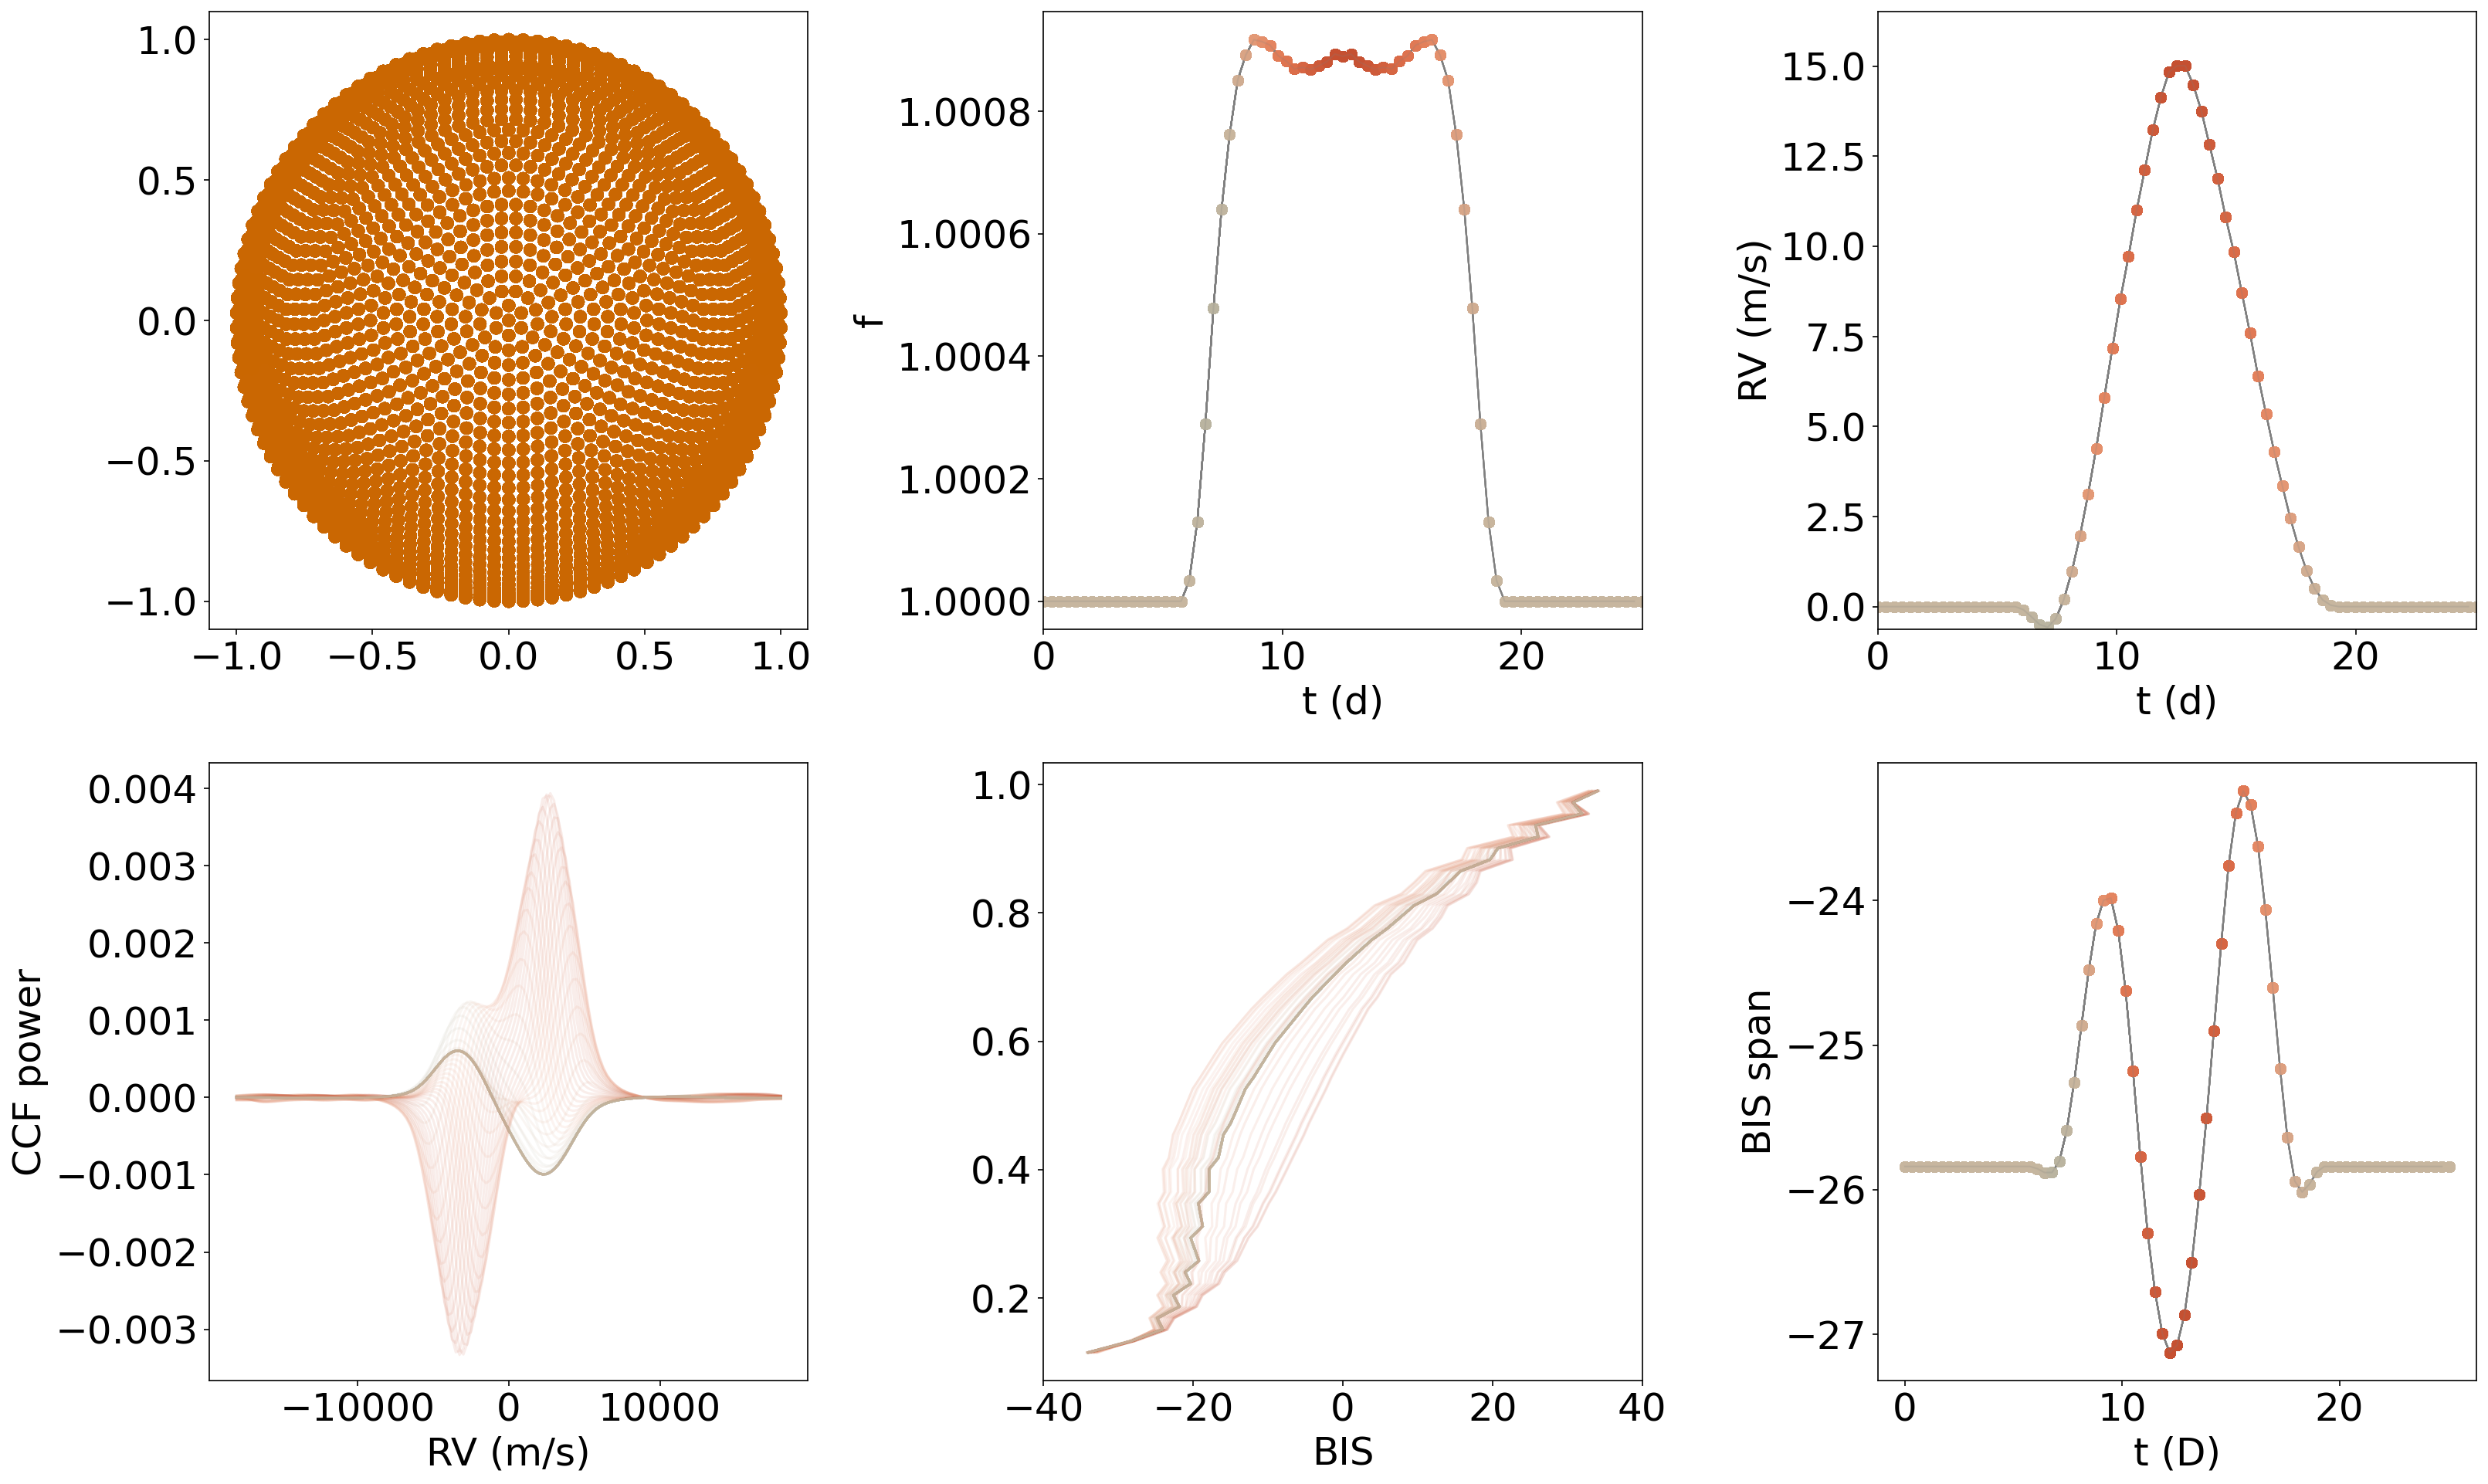

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

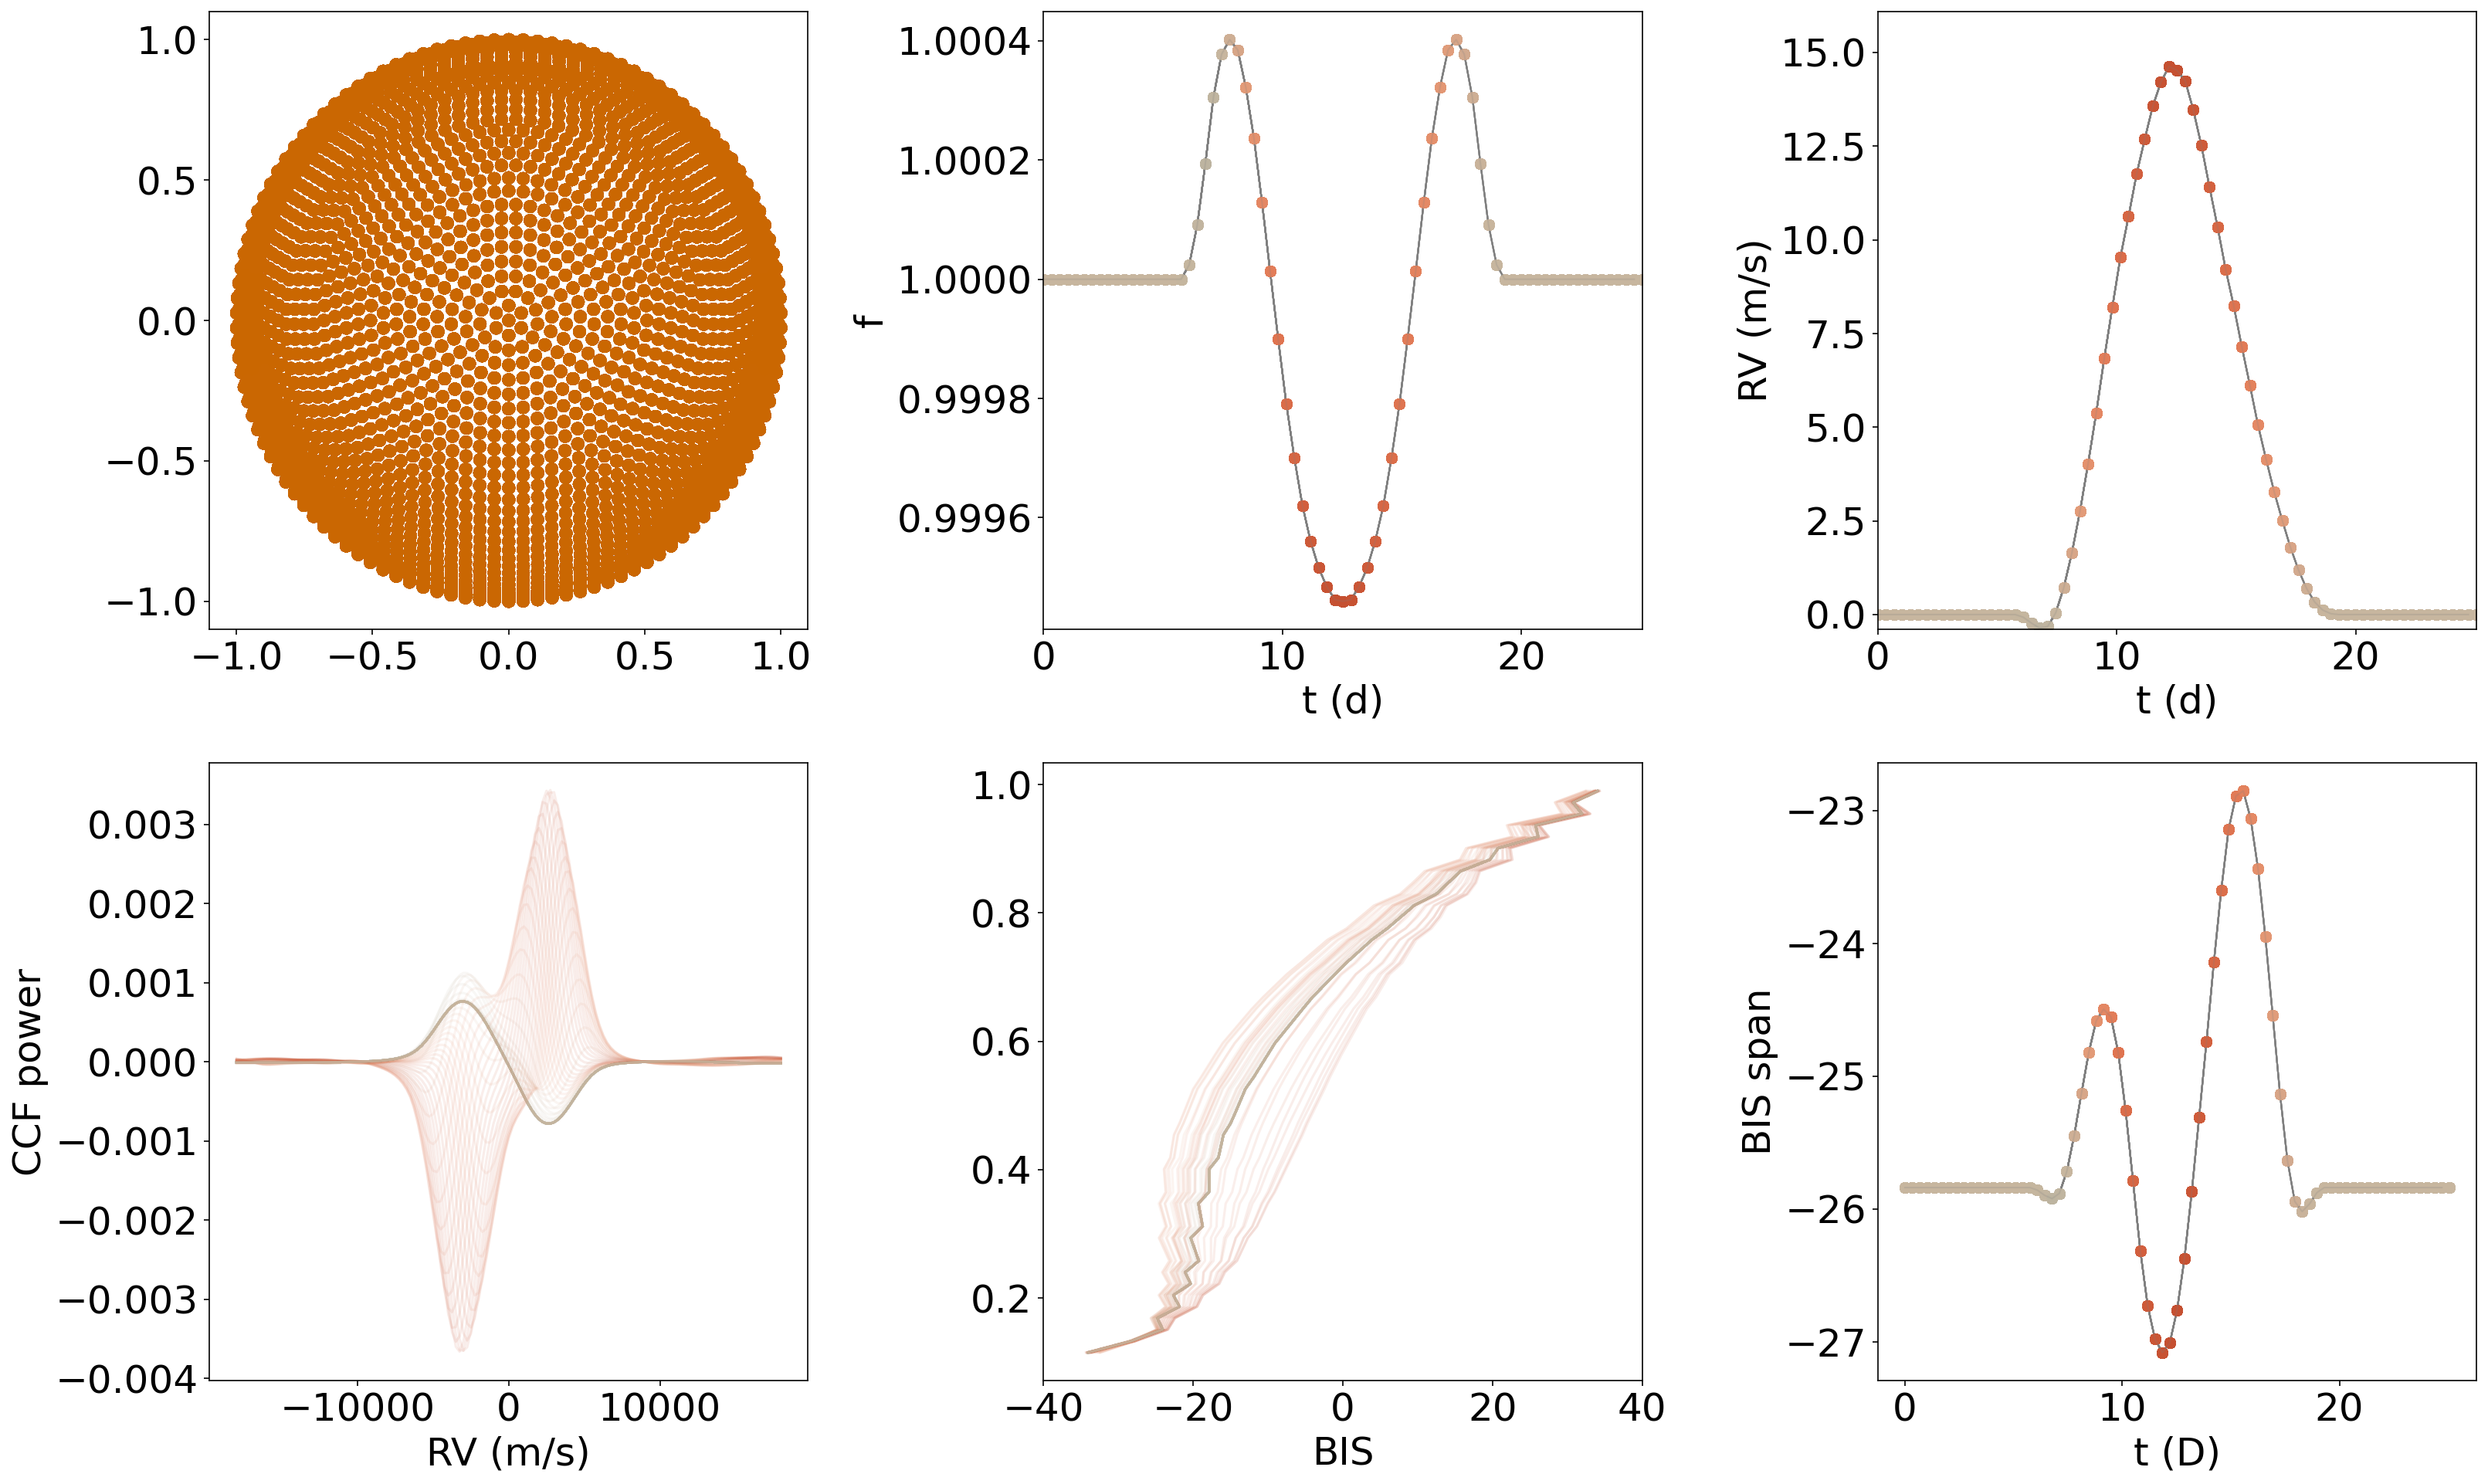

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

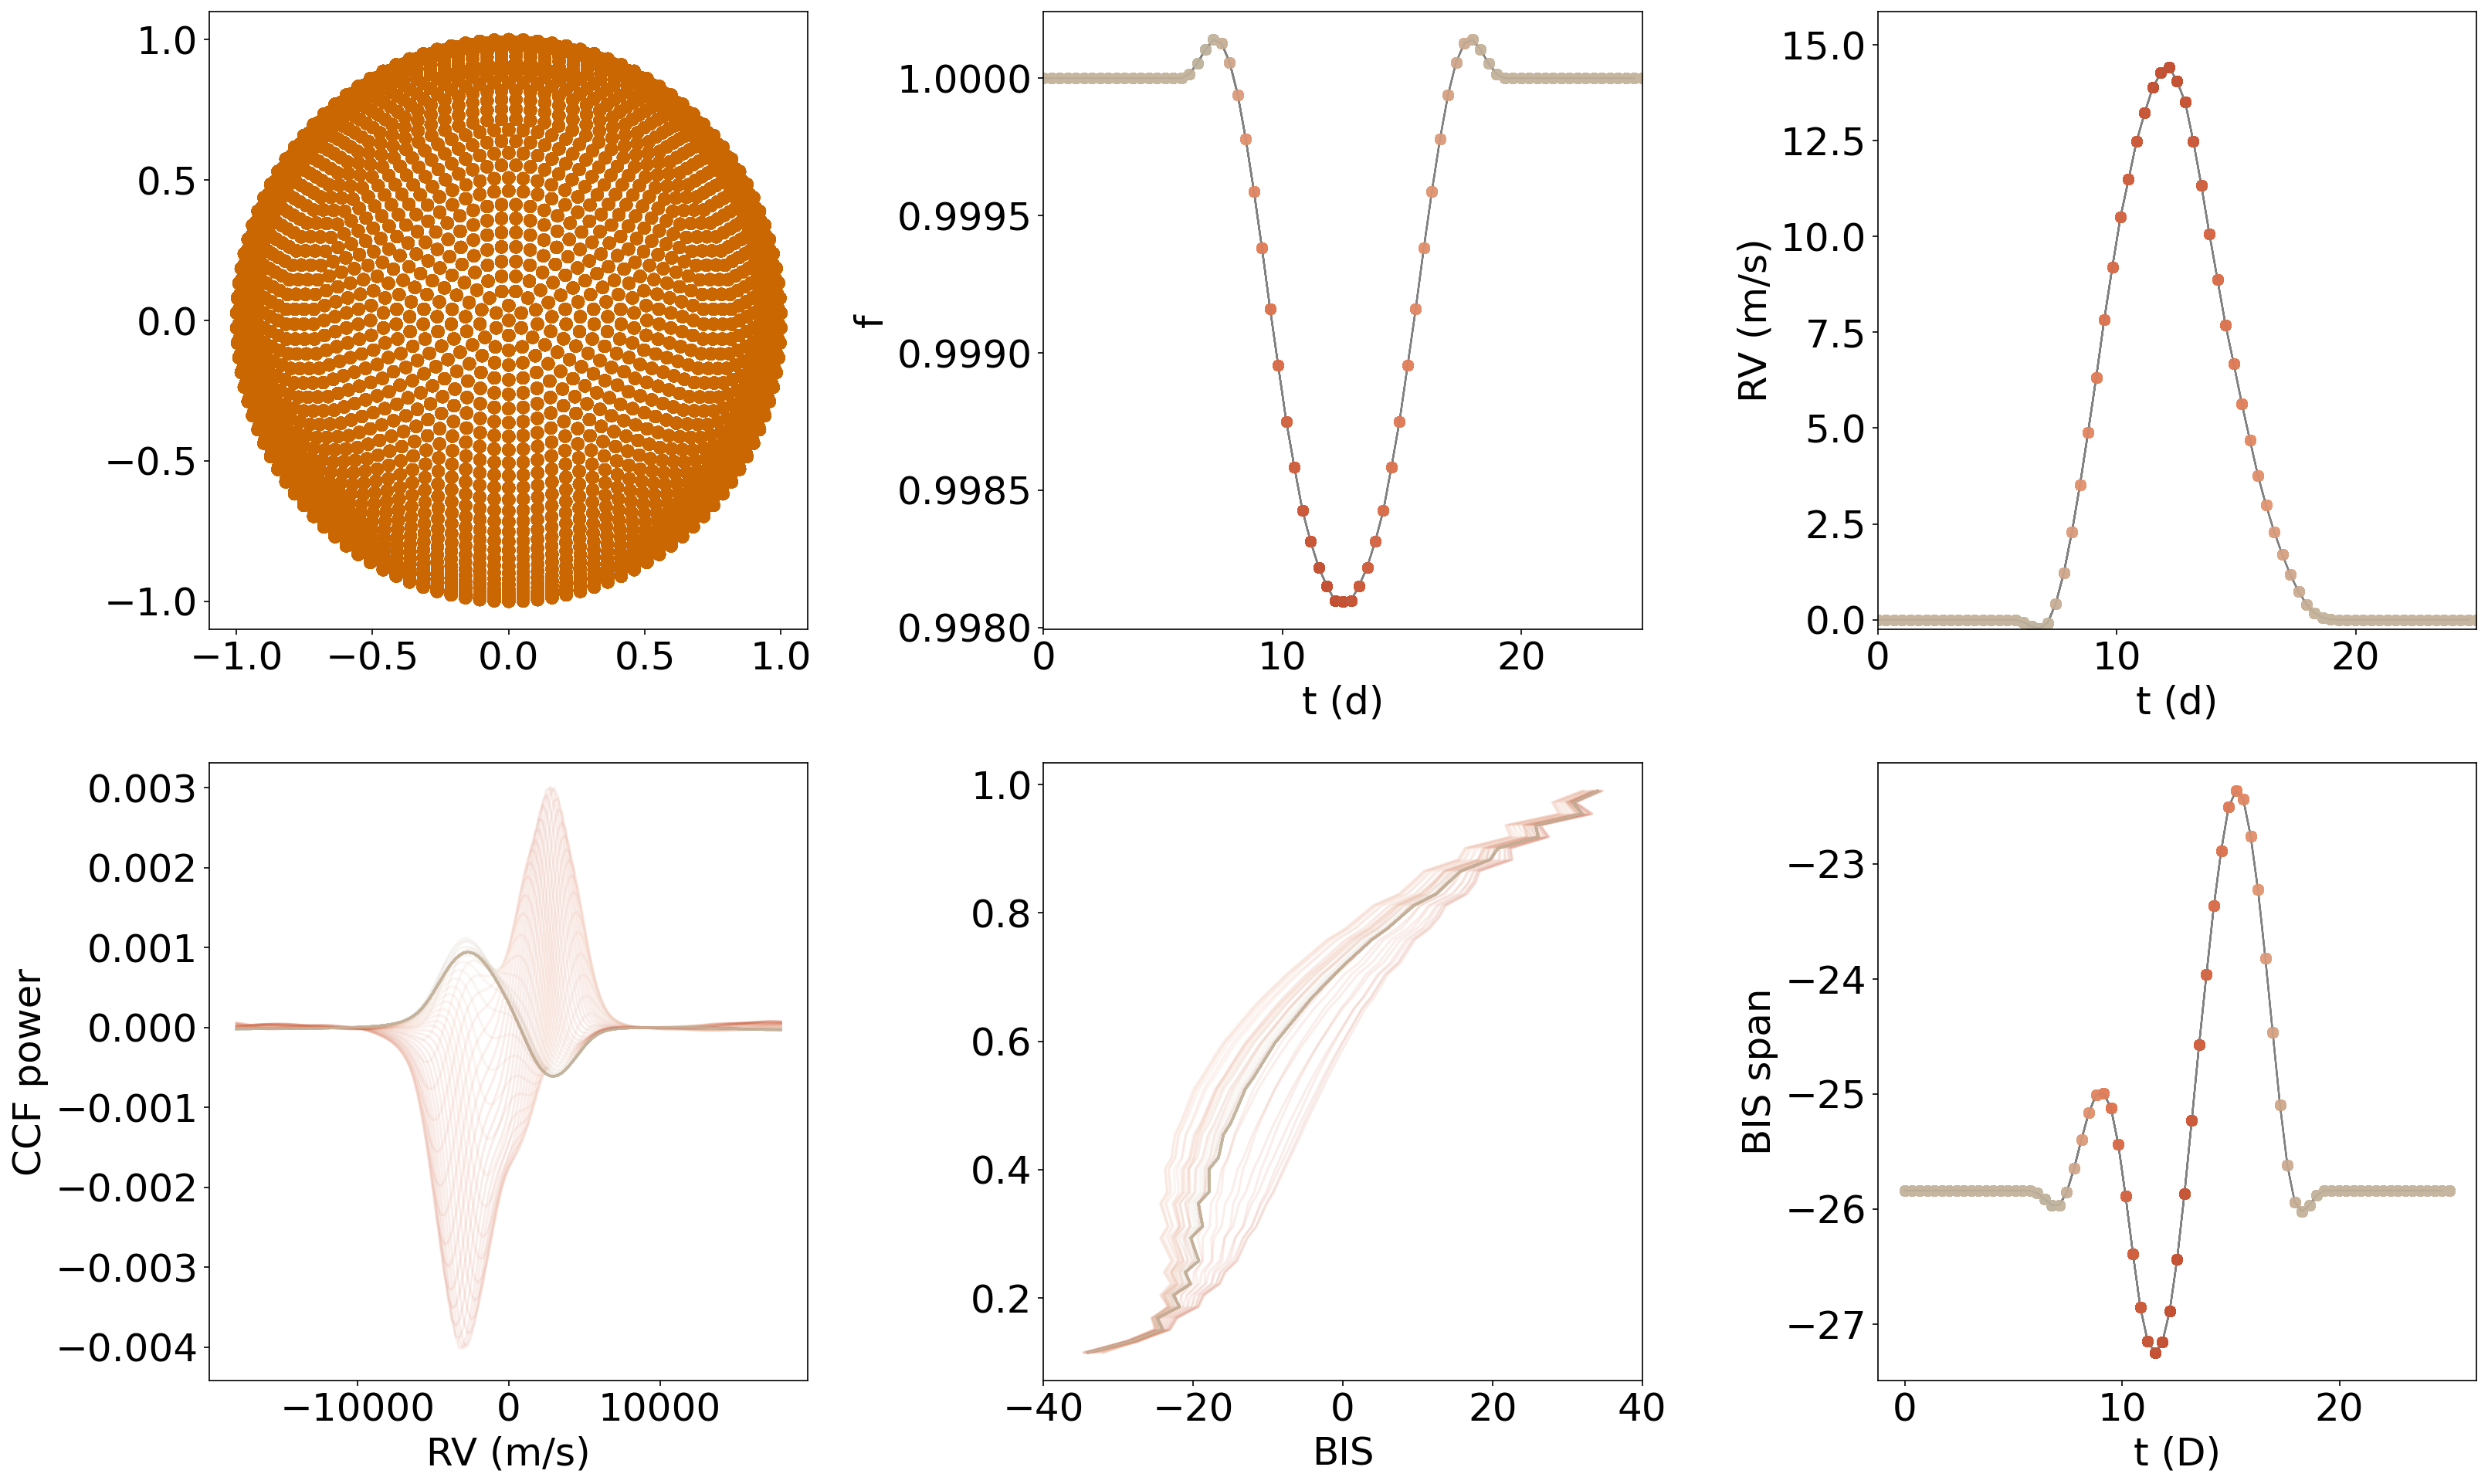

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

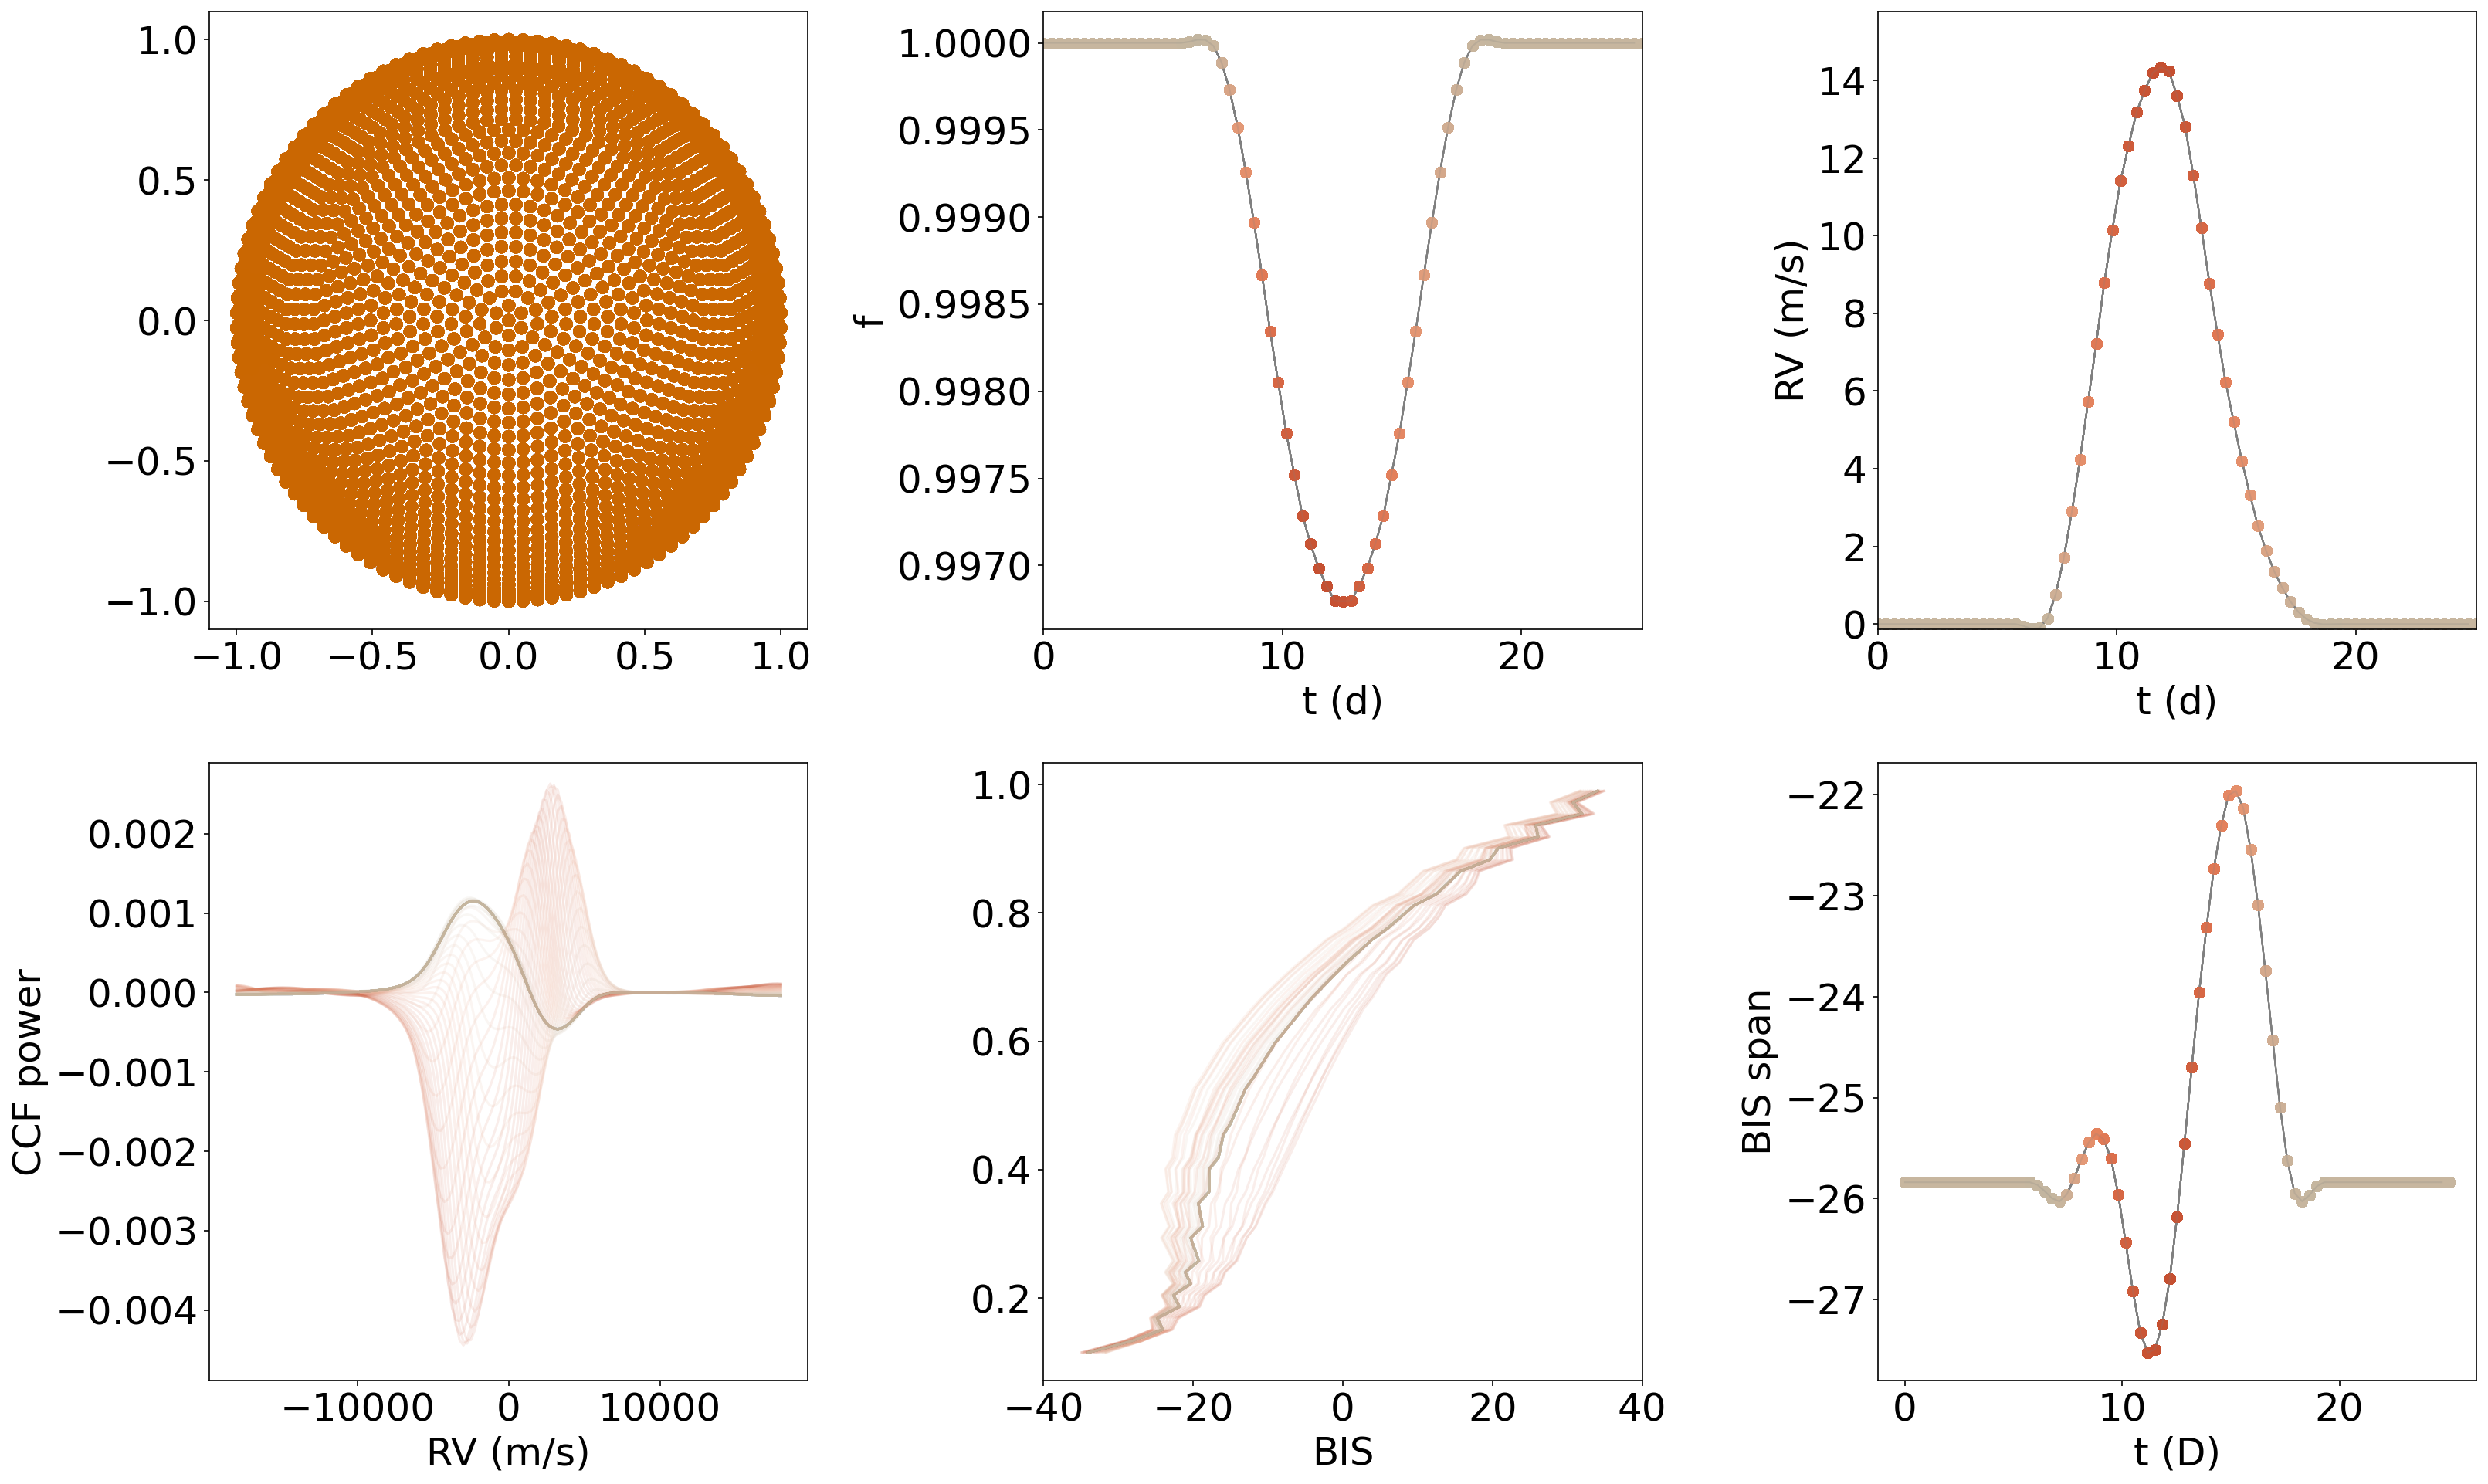

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

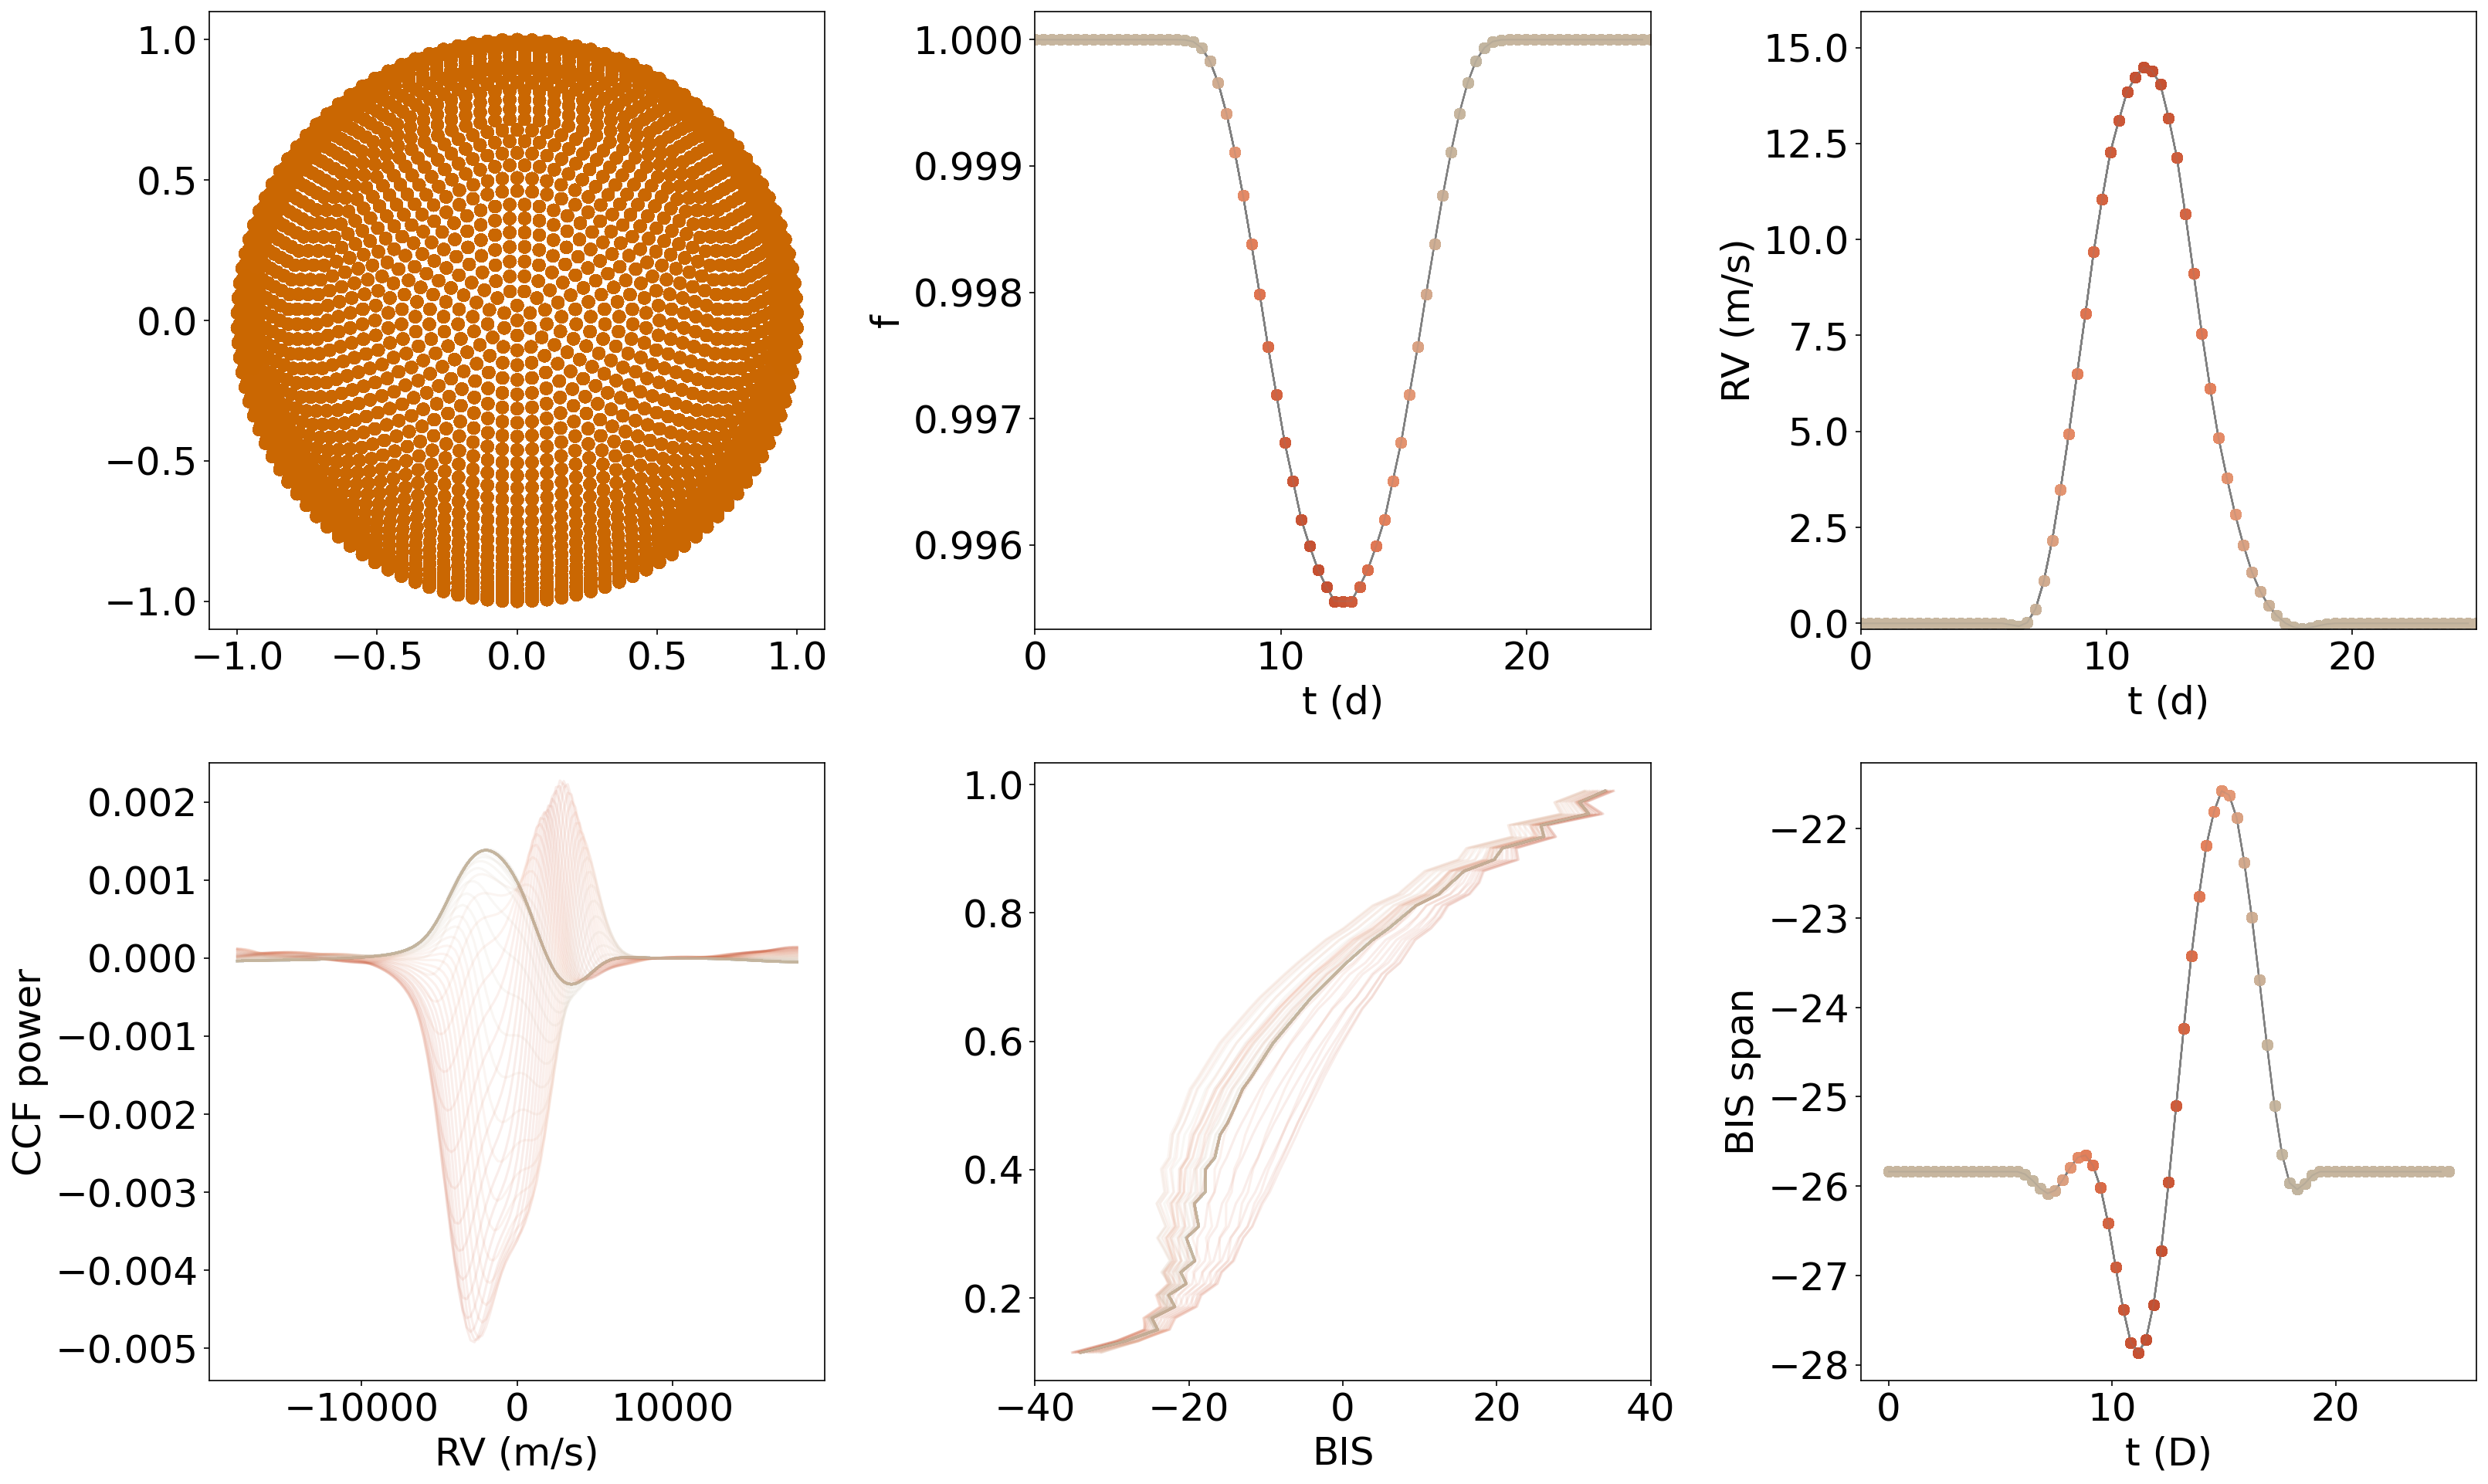

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

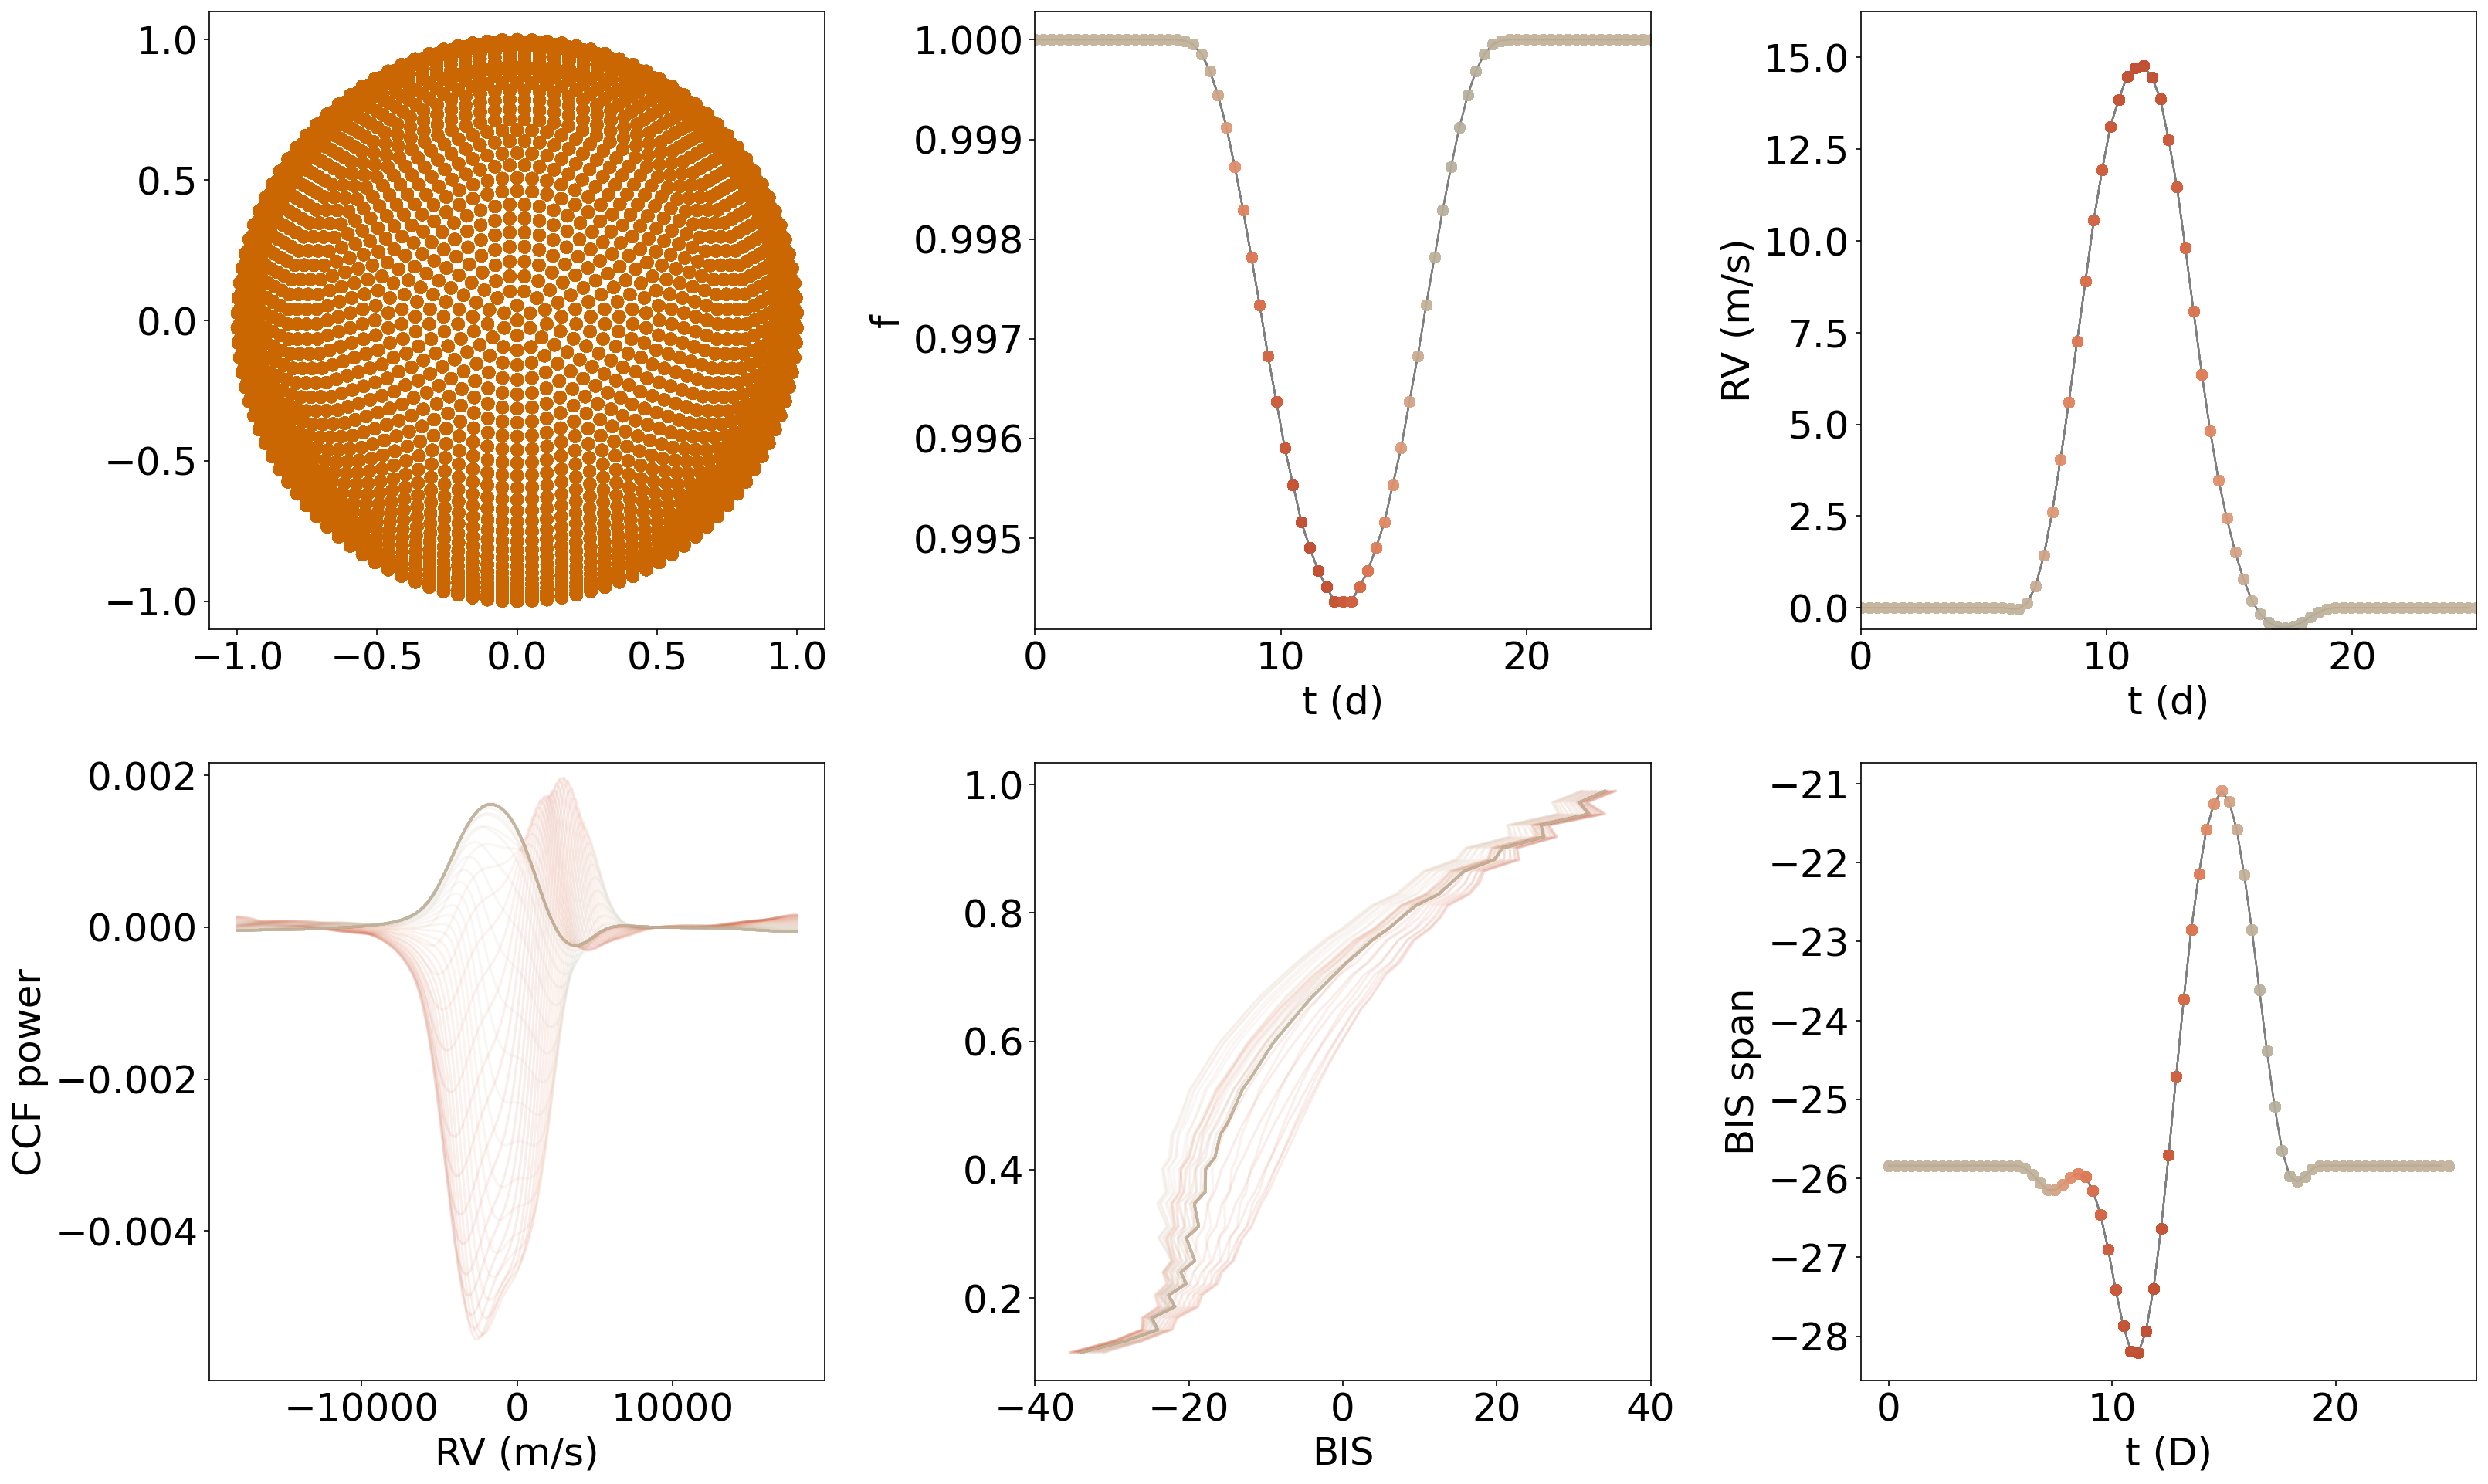

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

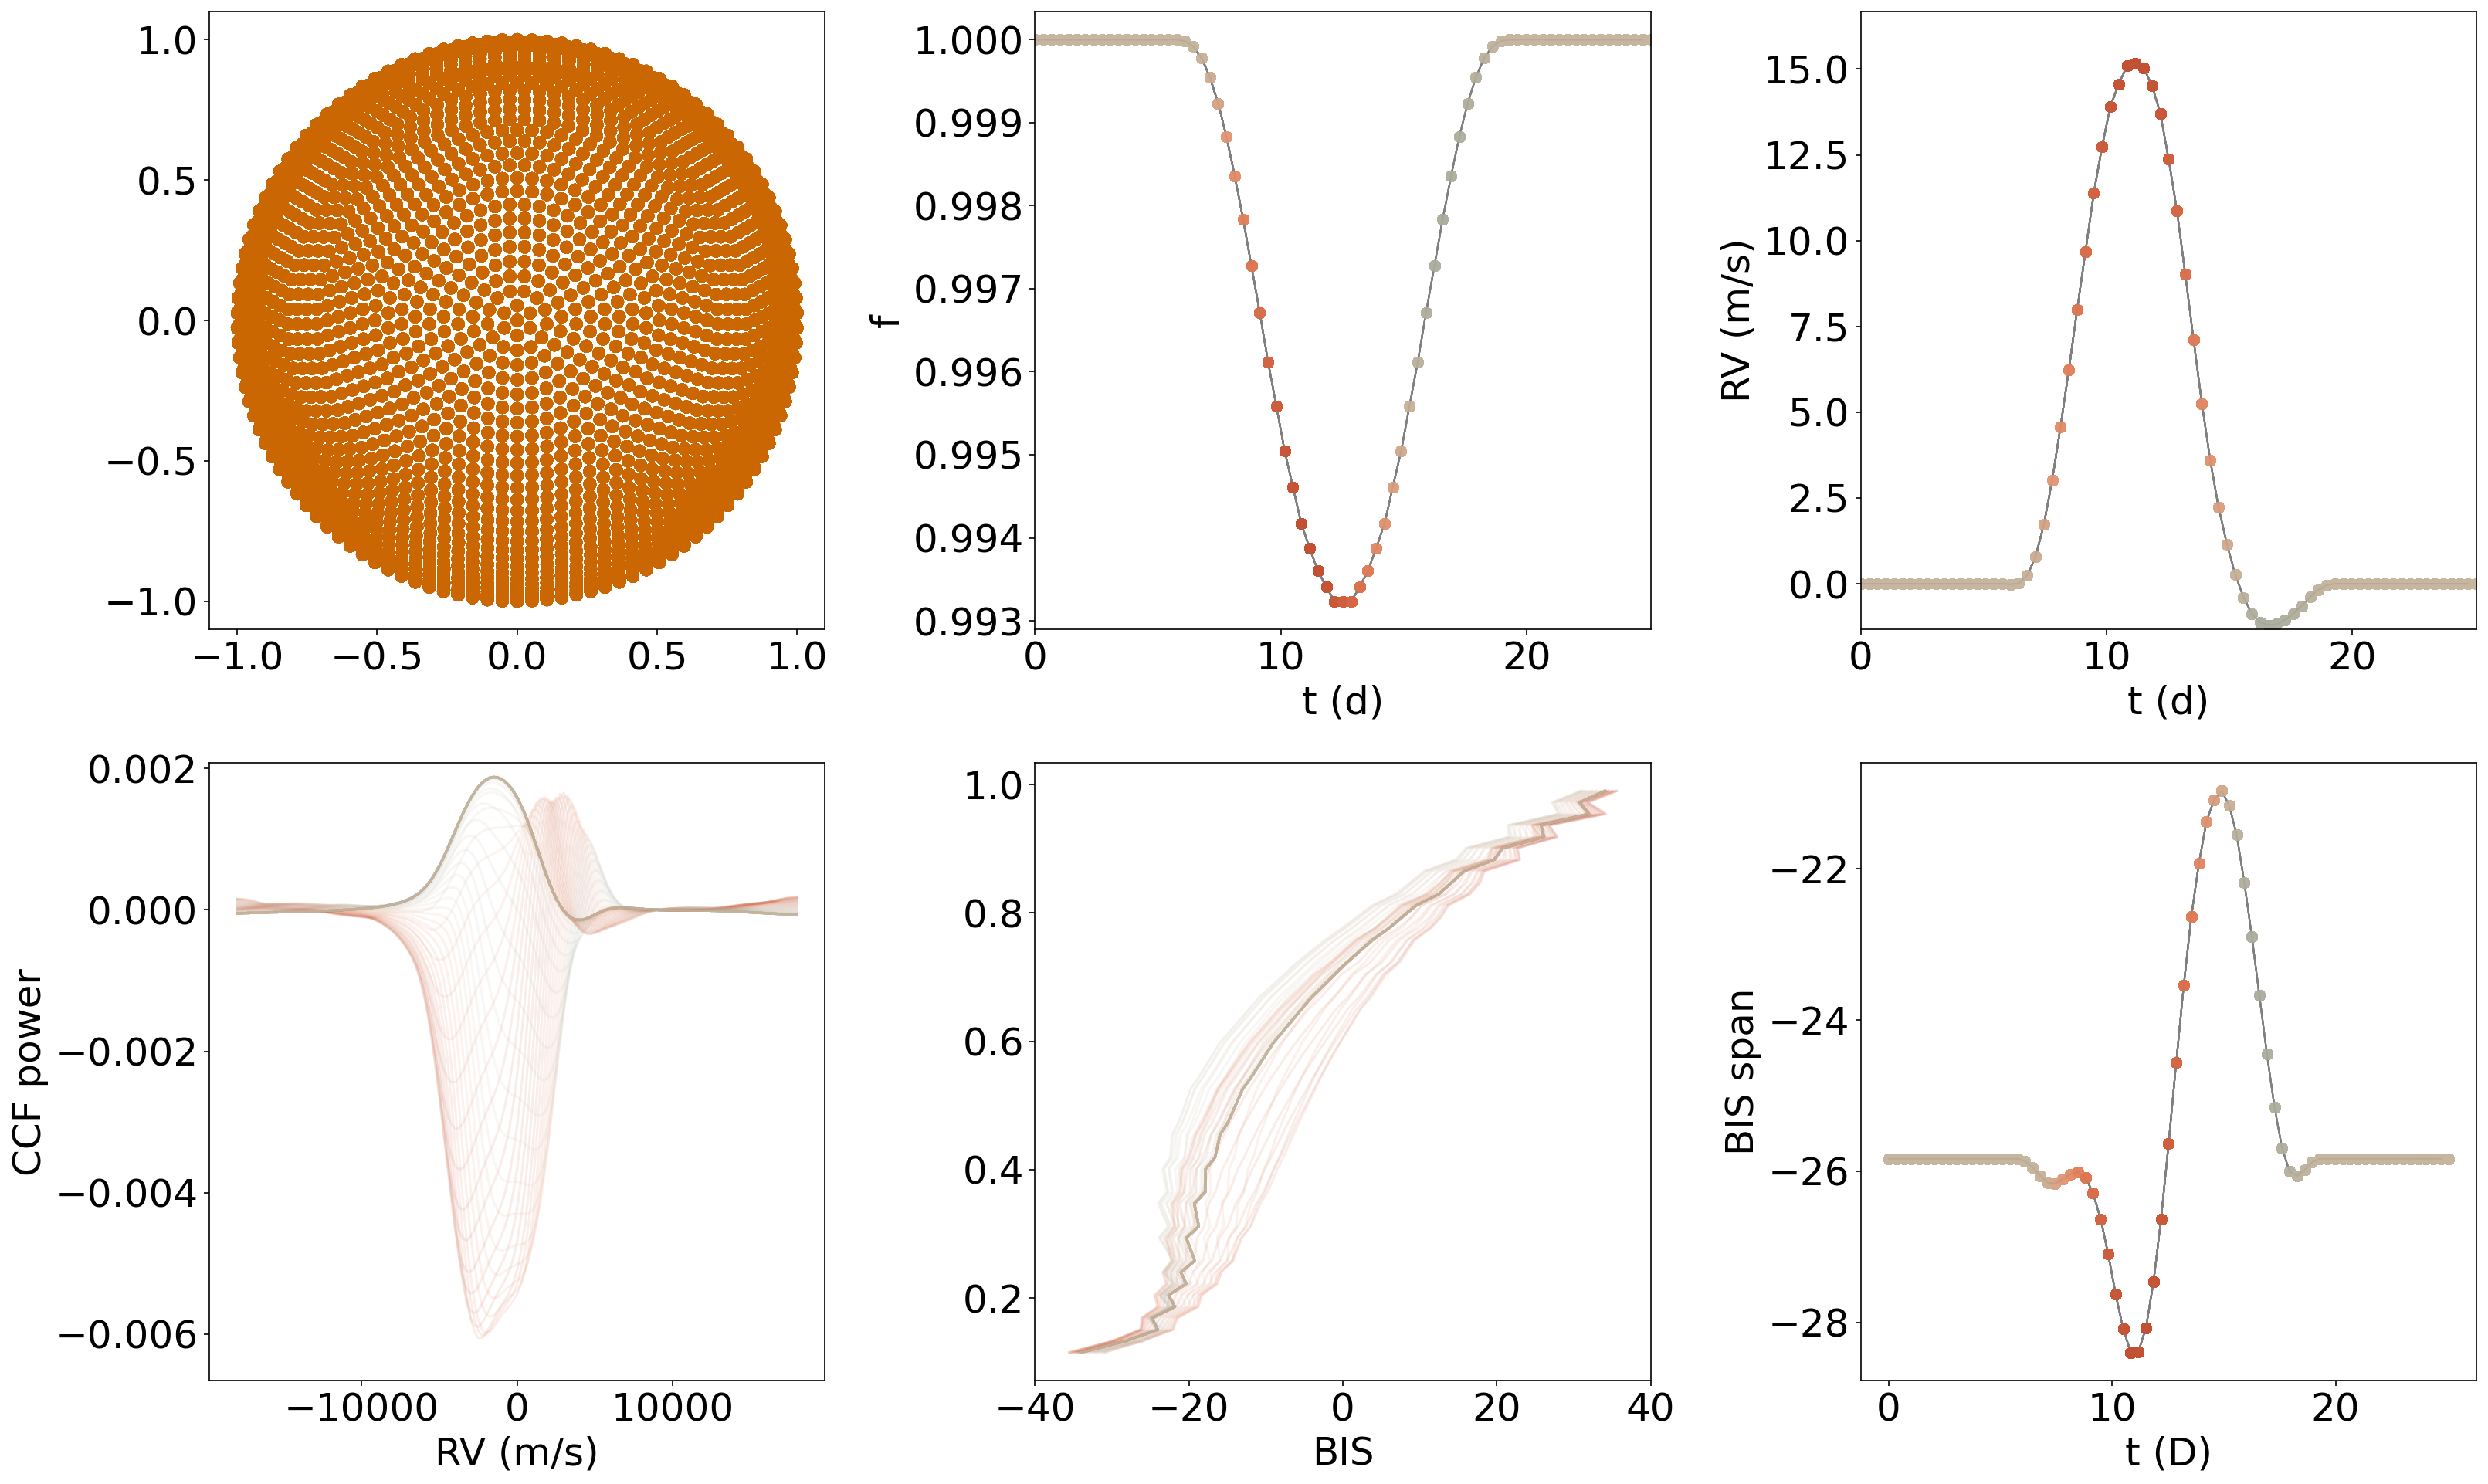

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

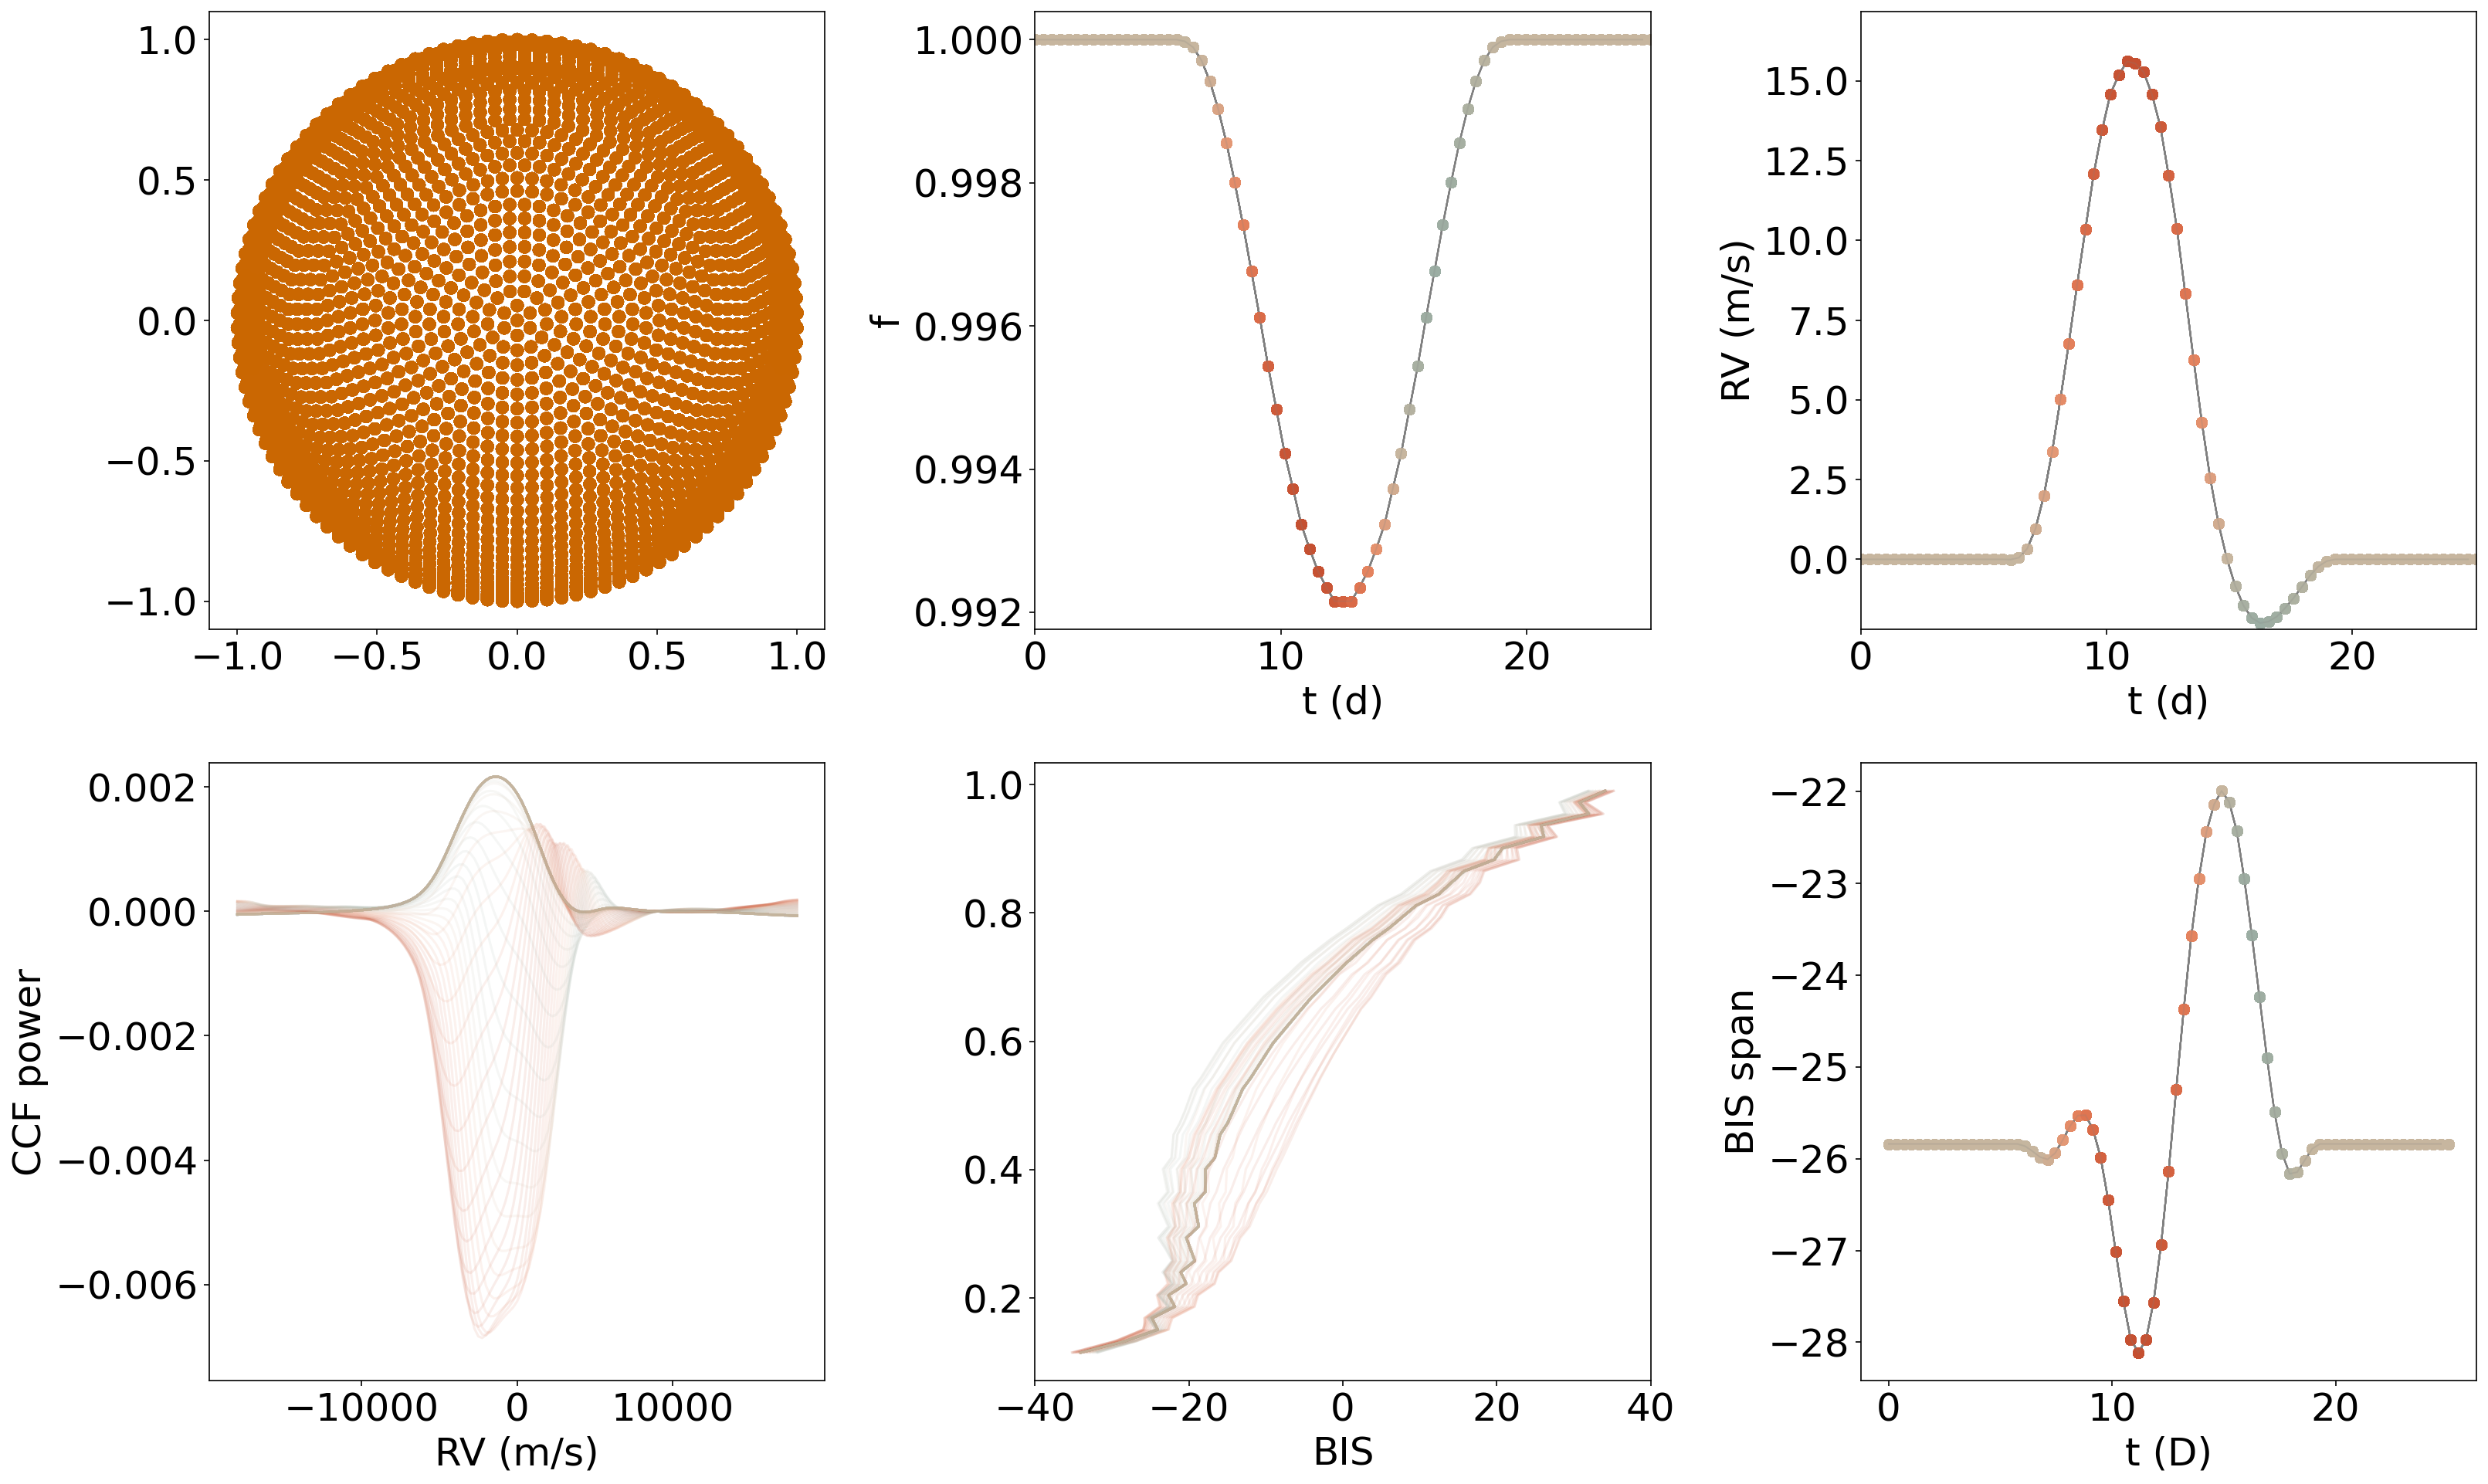

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

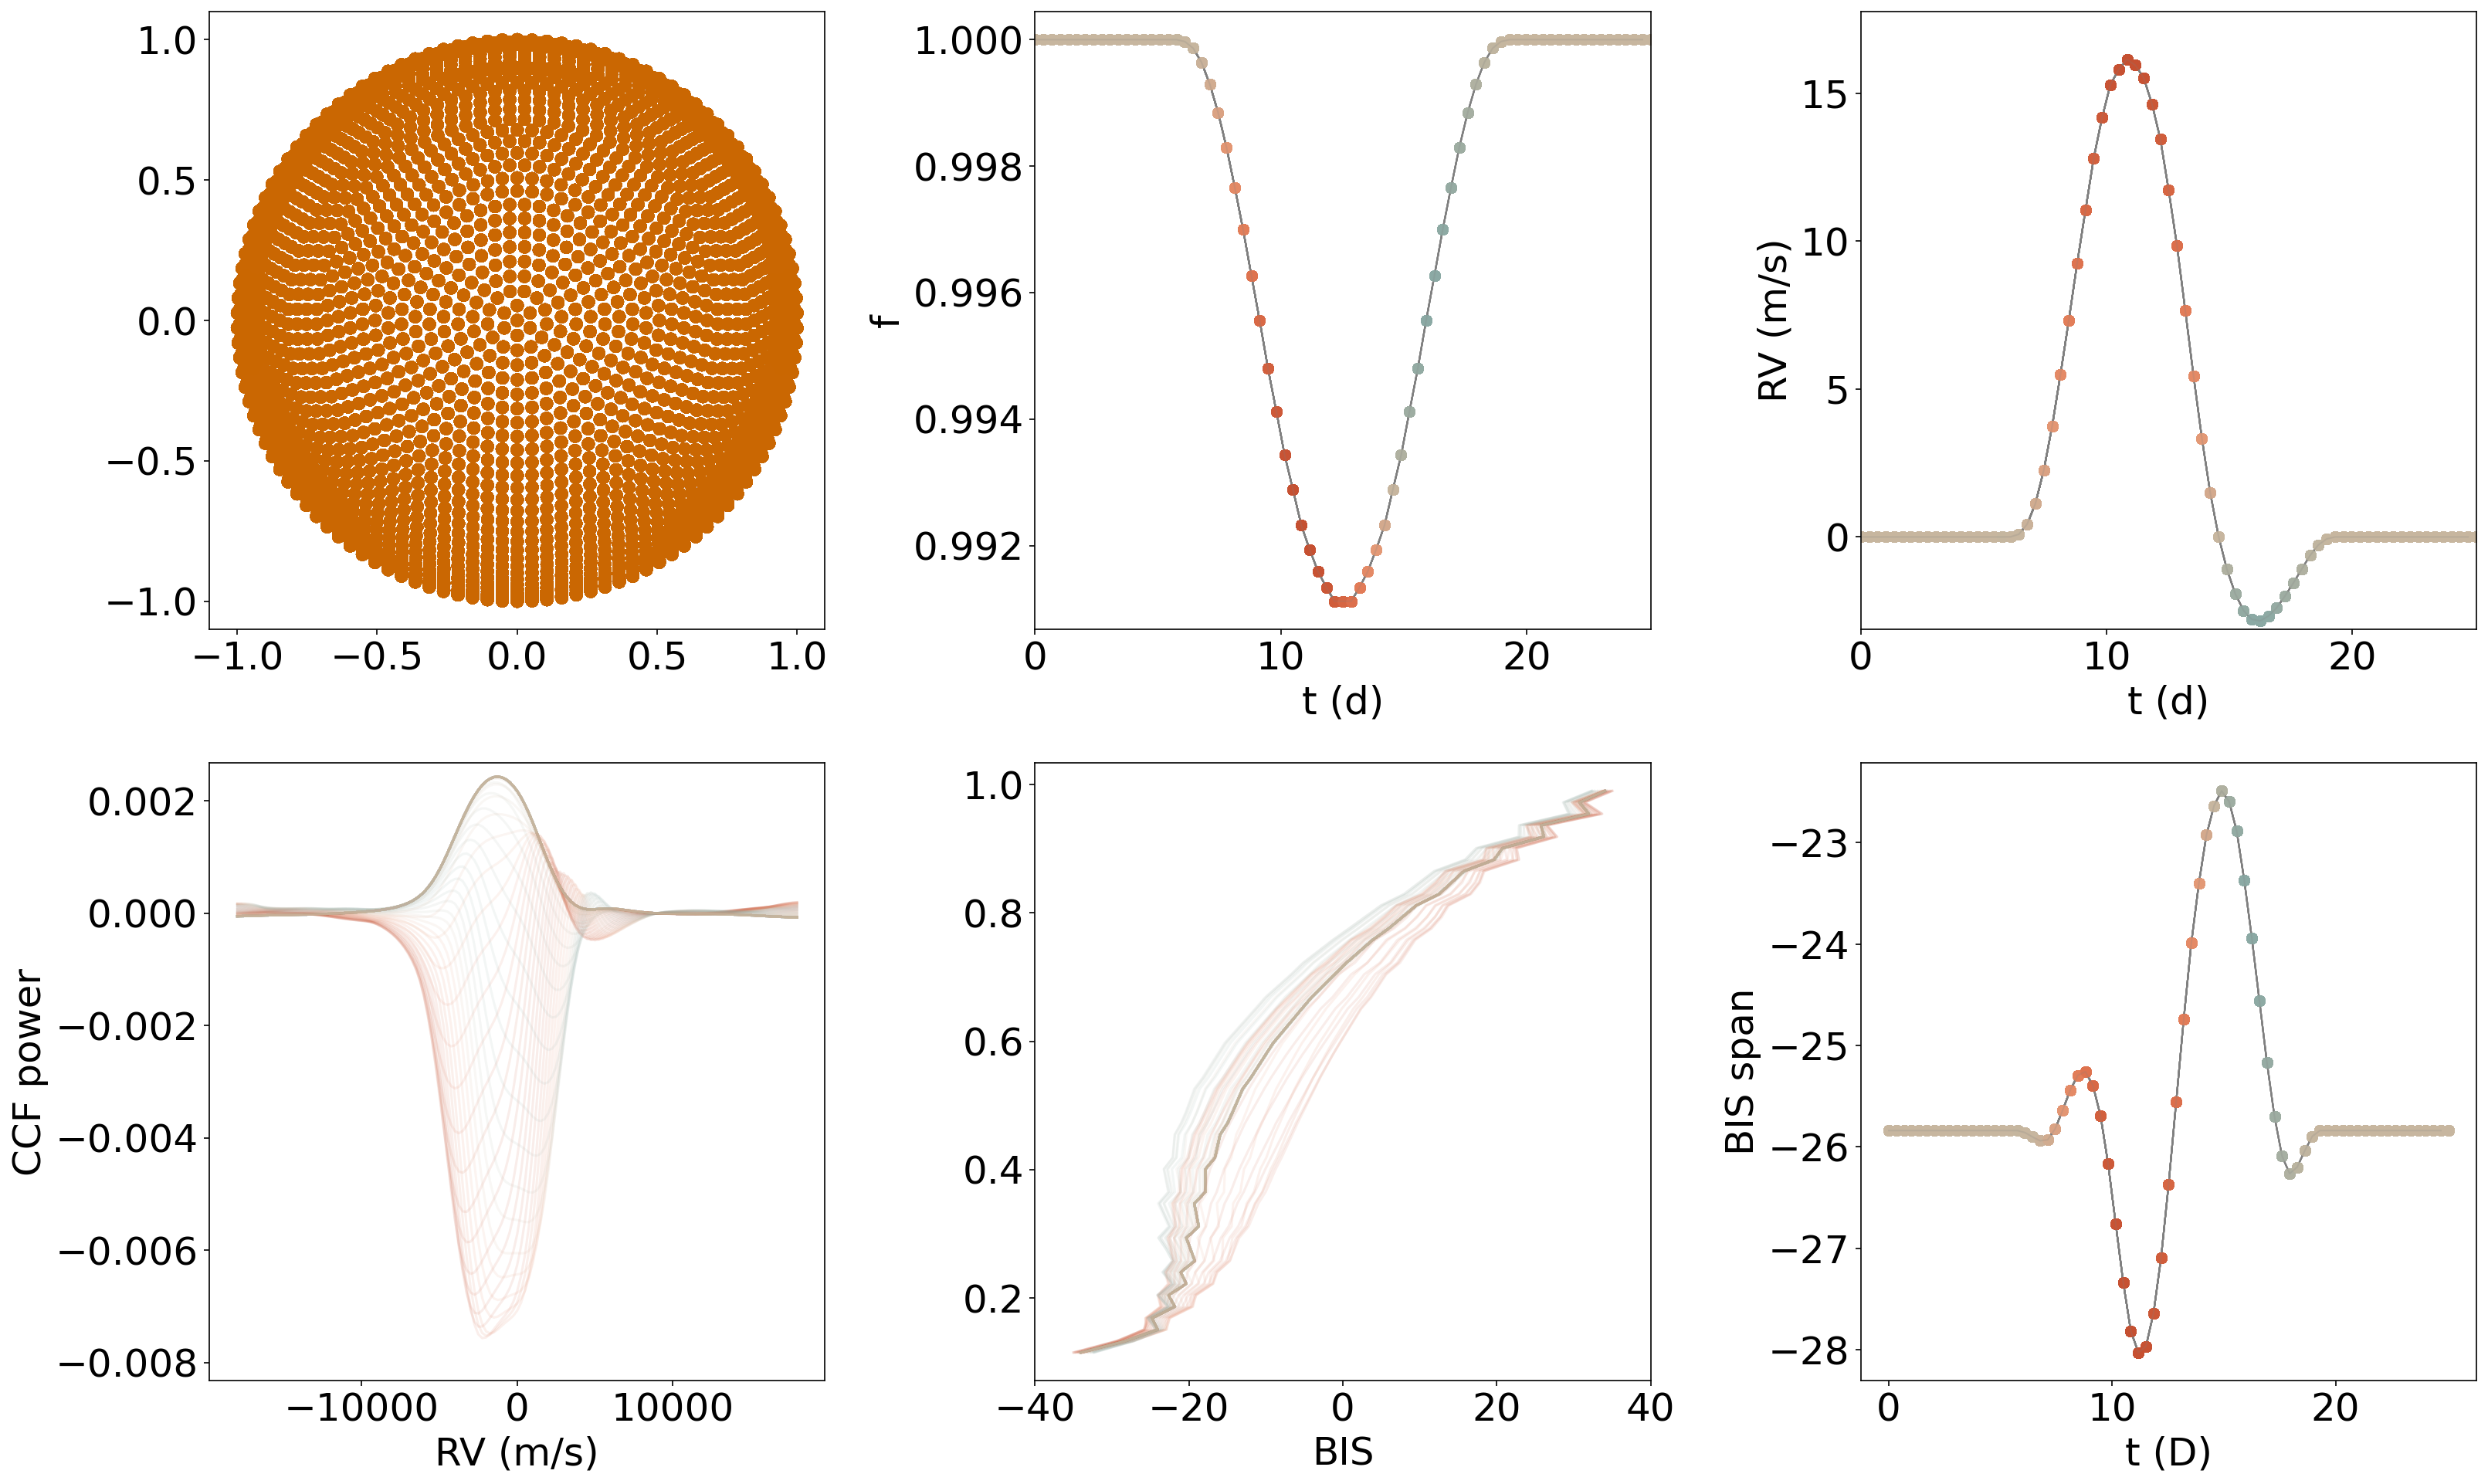

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%range ccf 0.0 1.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%

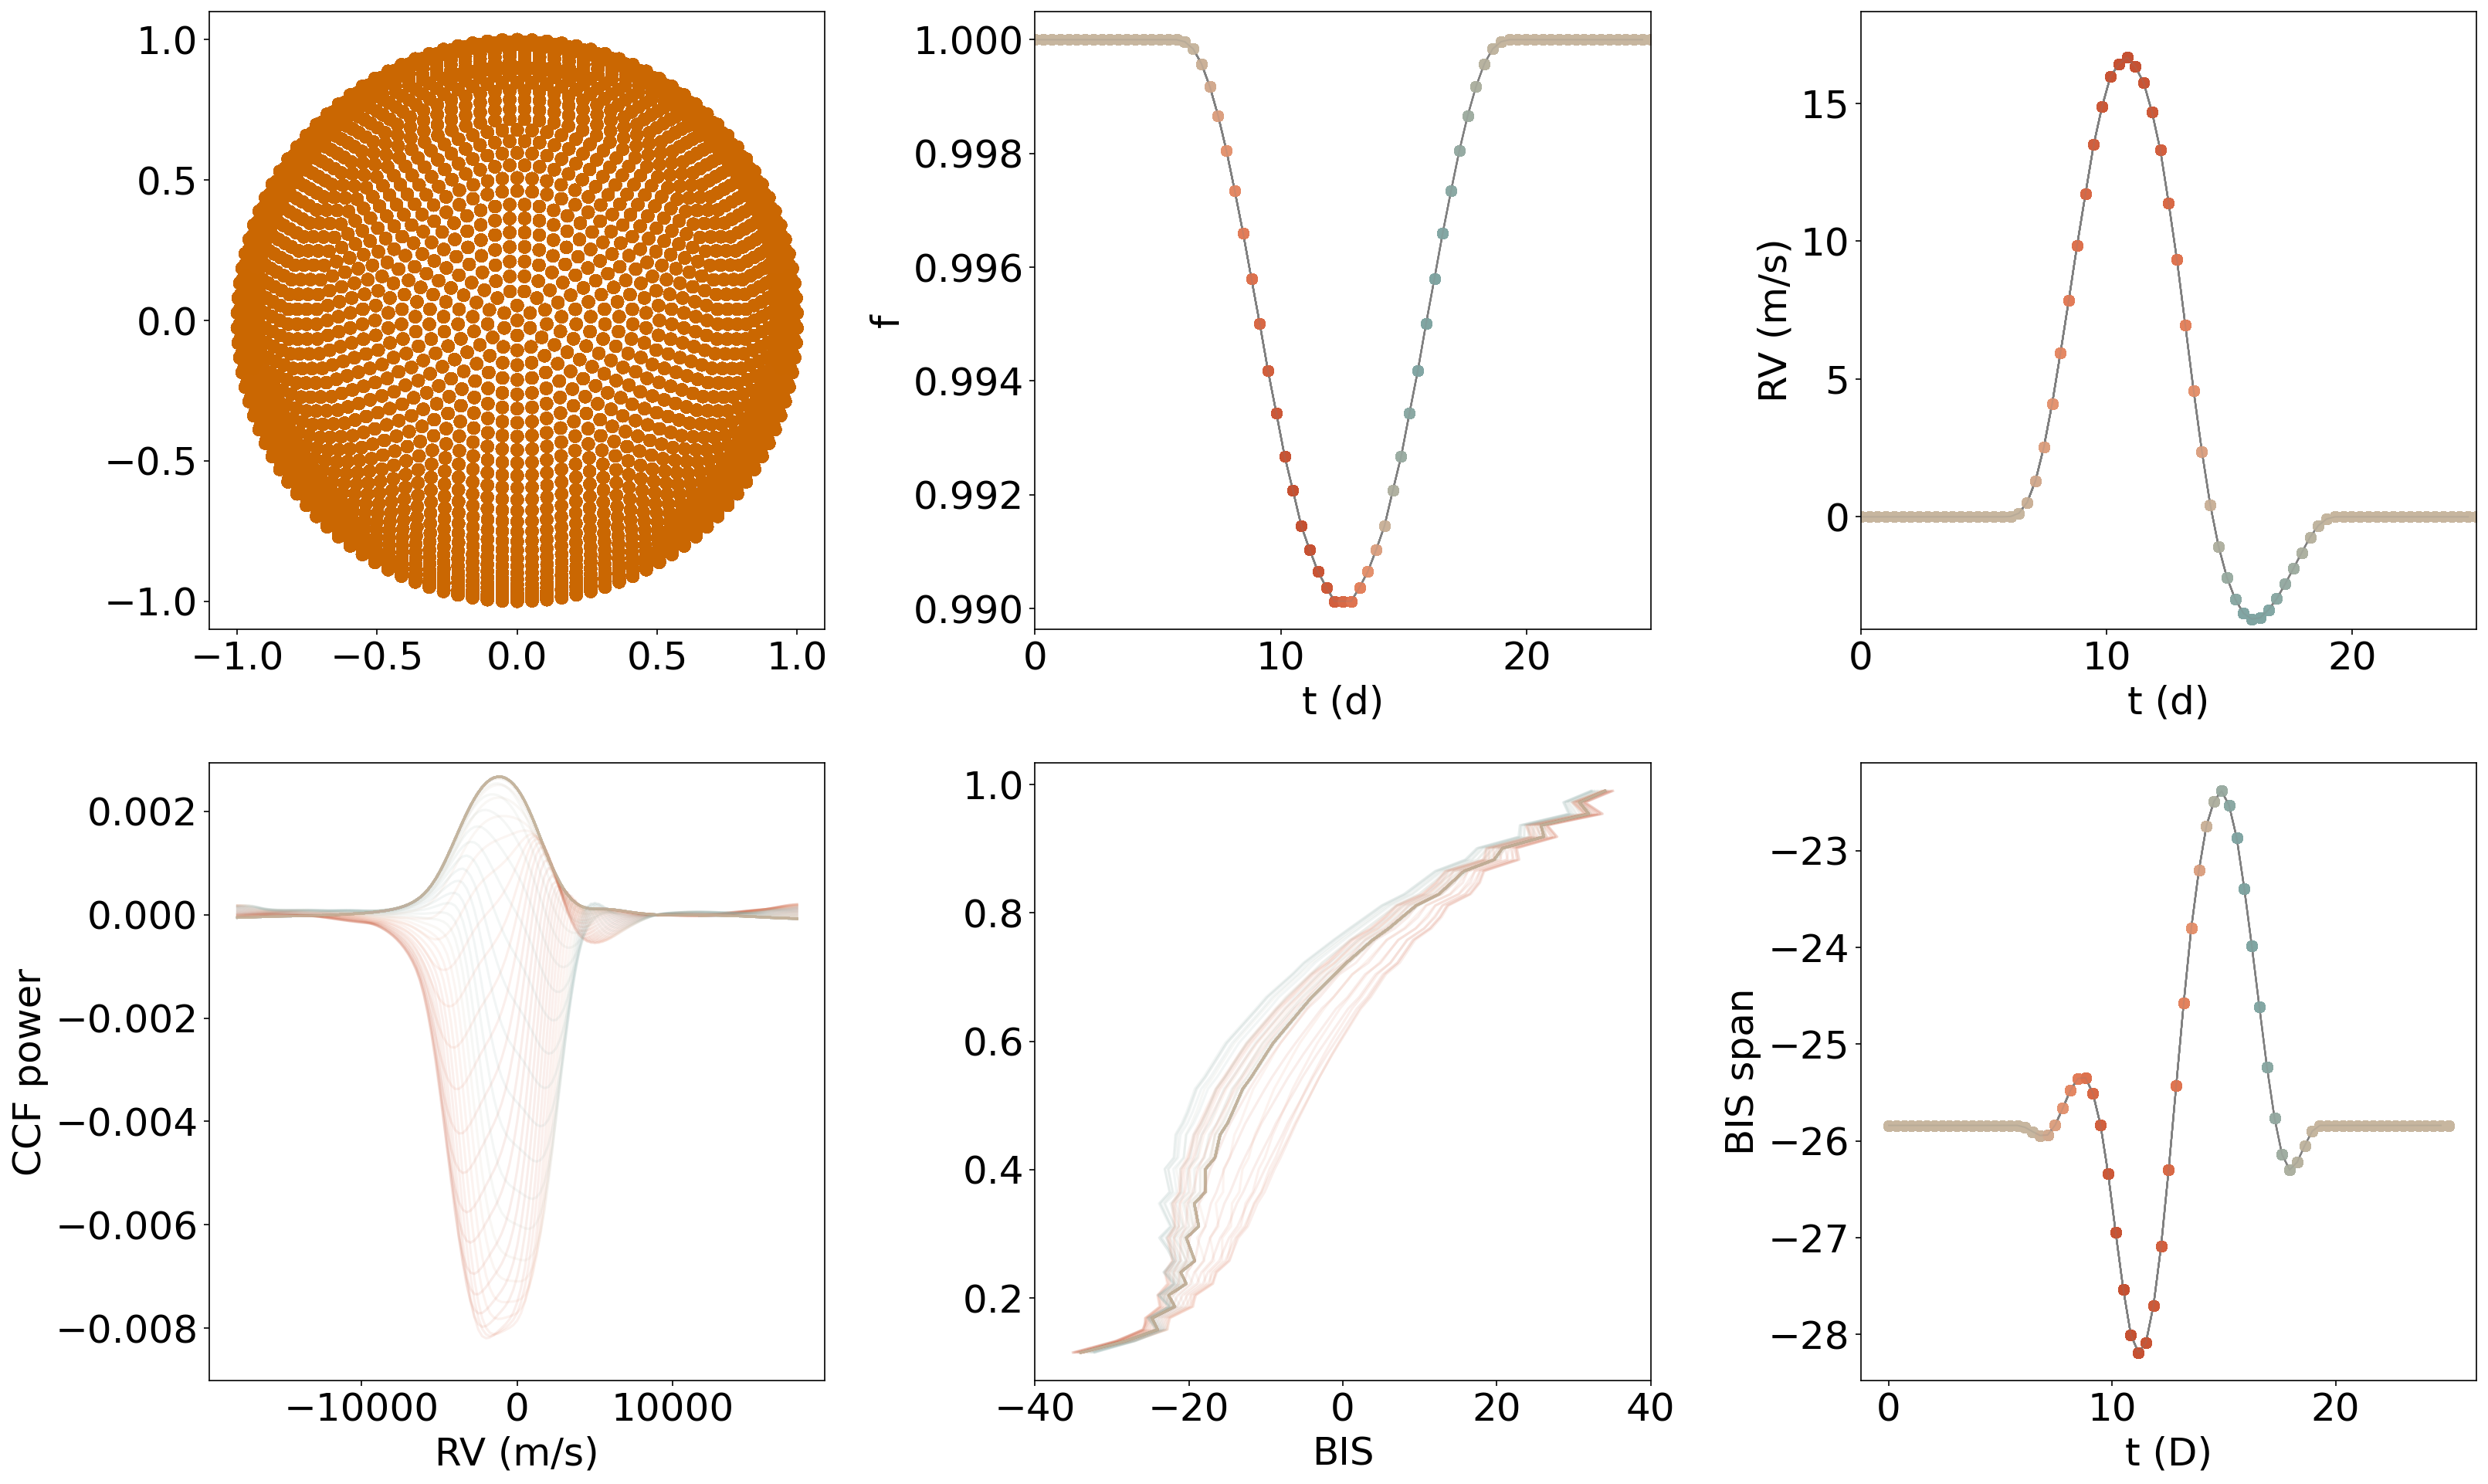

In [7]:
for spot_size in spot_size_list:
    for Q in Q_list["{:.2f}".format(spot_size)]:
        for lat in lat_list:
            for dT_fc in dT_fc_list:
                ss = simulation_routine(Q, [spot_size],[lat],[180], periods_nbr,point_nbr, conf_file_path,pathdata, path_grid, w='eq_2', dT_fc=dT_fc)
                flux_vs_dT.append(ss.results['lc'])
                RV_vs_dT.append(ss.results['rv'])
                BIS_vs_dT.append(ss.results['bis'])

                plt.show()

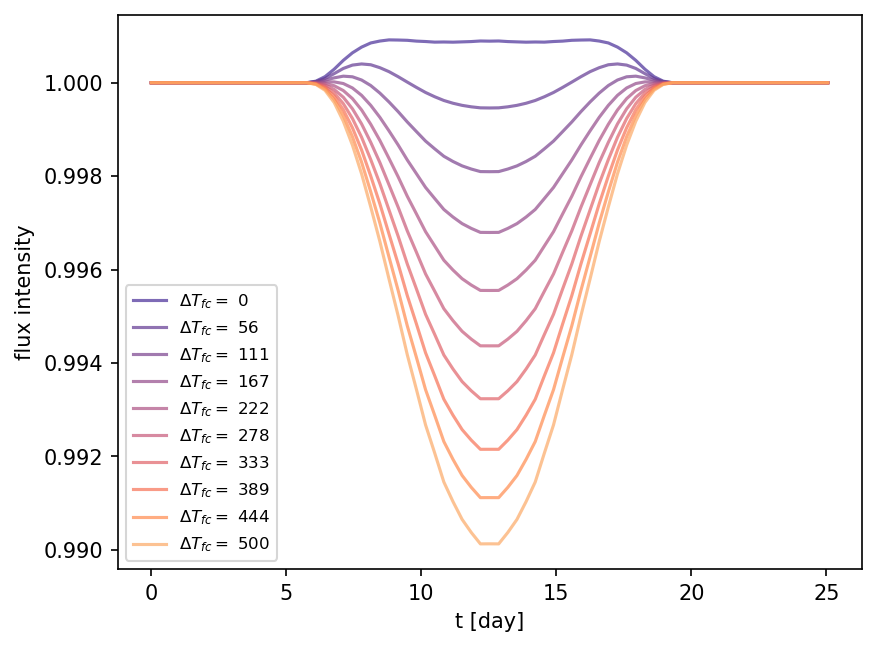

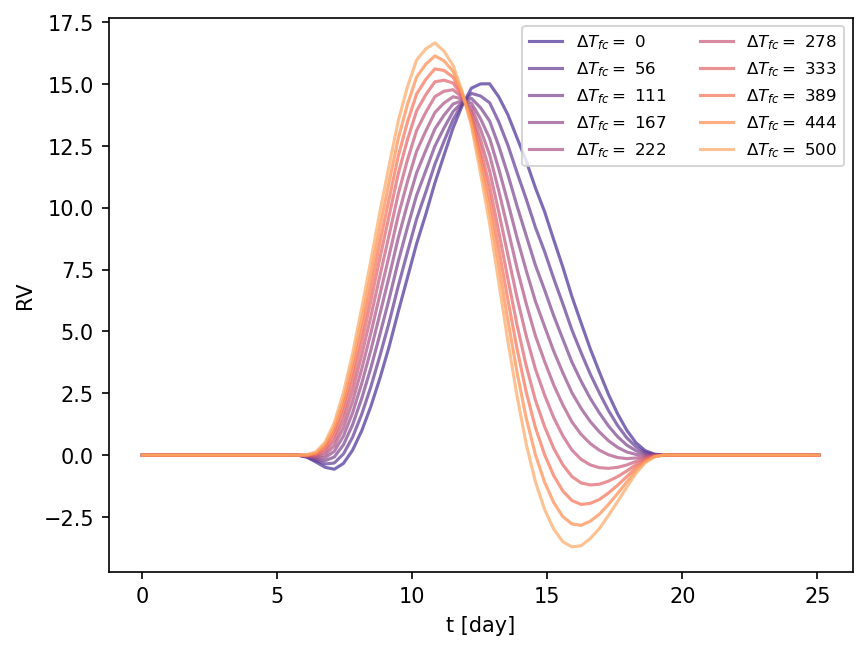

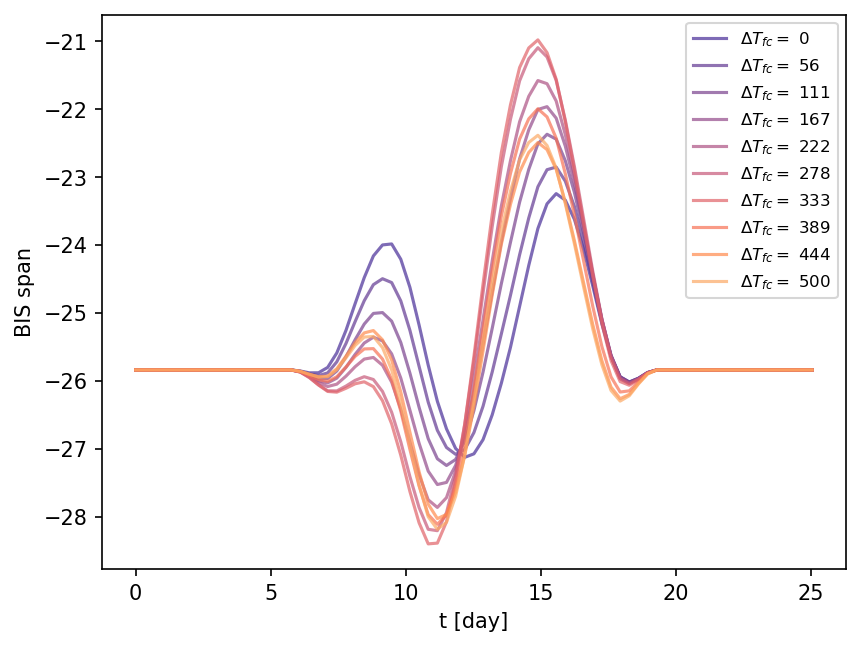

In [8]:
colors = cmr.take_cmap_colors('cmr.torch', n, cmap_range=(0.3, 0.8), return_fmt='hex')

t=np.linspace(0,ss.rotation_period*periods_nbr,len(flux_vs_dT[0]))
plt.rcParams['font.size'] = 10
for i in range(len(flux_vs_dT)):
    plt.plot(t, flux_vs_dT[i], color=colors[i], alpha=0.7, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))
    
plt.xlabel('t [day]')
plt.ylabel('flux intensity')
plt.legend(fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/flux_vs_dT_fc_T_eff_{:.0f}.pdf'.format(ss.temperature_photosphere), dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(flux_vs_dT)):
    plt.plot(t, RV_vs_dT[i], color=colors[i], alpha=0.7, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))
    
plt.xlabel('t [day]')
plt.ylabel('RV')
plt.legend(ncol=2, fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/RV_vs_dT_fc_T_eff_{:.0f}.pdf'.format(ss.temperature_photosphere), dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(flux_vs_dT)):
    plt.plot(t, BIS_vs_dT[i], color=colors[i], alpha=0.7, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))
    
plt.xlabel('t [day]')
plt.ylabel('BIS span')
plt.legend(ncol=1, fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/BIS_vs_dT_fc_T_eff_{:.0f}.pdf'.format(ss.temperature_photosphere), dpi=200, bbox_inches='tight')
plt.show()

In [16]:
periods_nbr = 2
data_per_day = 6
point_nbr = int(25.67*data_per_day*periods_nbr)
lat_list = np.linspace(90, 179, 3)
transit_period = []

for lat in lat_list:
    ss = simulation_init(0, [5], [lat], [90], conf_file_path, periods_nbr, point_nbr=point_nbr)
        
    t=np.linspace(0,25.67*periods_nbr,point_nbr)

    ss.compute_forward(observables=['rv'],t=t)
    pos = np.squeeze(ss.results['pos'])
    phi = pos[:,1]            
    idx = np.argwhere(np.abs(phi-phi[0])<0.03)
    i = np.squeeze(idx[np.argwhere(idx>20*data_per_day)][0])[0]
    transit_period.append(t[i])


range ccf 0.0 1.0
Date 9.532182410423454. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [58/308]%%

KeyboardInterrupt: 

In [ ]:
lat_list = np.linspace(90, 180, 100)
w = 360 / 25.67 - 2.396 * np.sin(np.deg2rad(90-lat_list))**2 - 1.7887 * np.sin(np.deg2rad(90-lat_list))**4
T = 360 / w

pht =  1 / 25.67  - 1 * (1.698*np.cos(np.deg2rad(lat_list))**2+2.346*np.cos(np.deg2rad(lat_list))**4) / 360



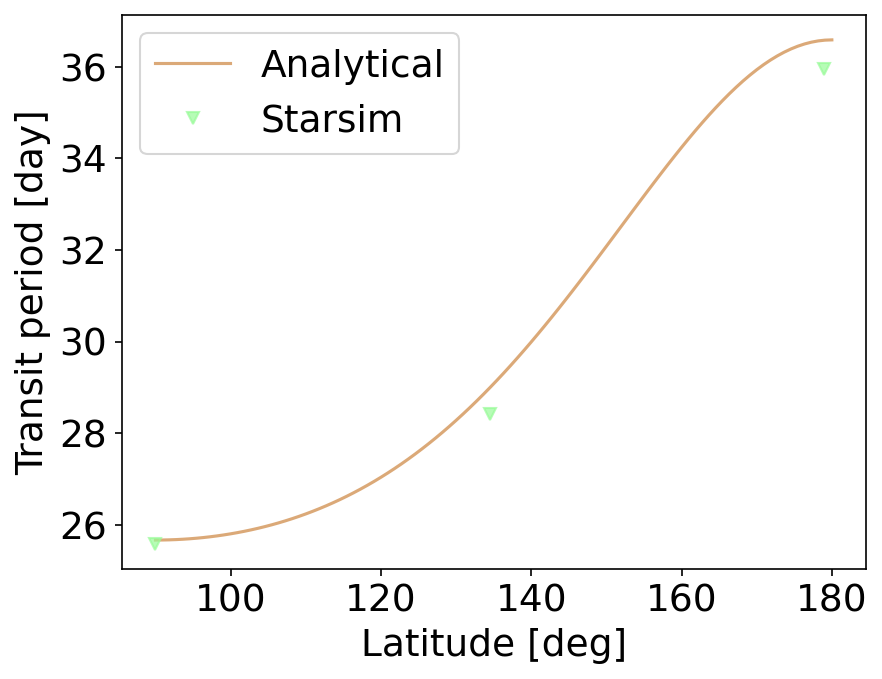

In [ ]:
plt.errorbar(np.linspace(90, 179, 3), transit_period, marker = 'v', linestyle='', color='palegreen', alpha = 0.7, label='Starsim')
plt.plot(lat_list, T, color='peru', alpha=0.7, label='Analytical')
#plt.plot(lat_list, fit)
plt.xlabel('Latitude [deg]')
plt.ylabel('Transit period [day]')
plt.legend()
plt.savefig(pathdata+'transit_period_vs_lat_k_-1.pdf', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'T' is not defined

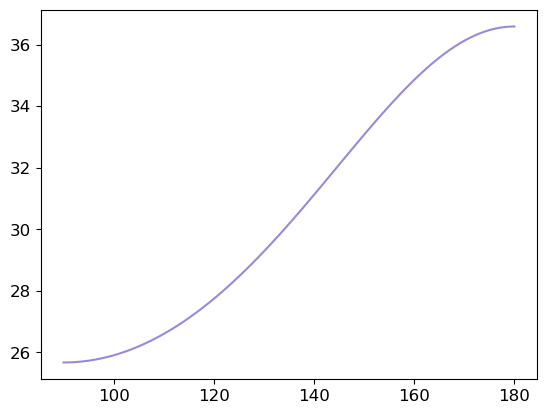

In [ ]:
theta = np.linspace(np.deg2rad(90), np.deg2rad(180), 100)
rotation_period_lat = 1/(1/ 25.67  + (-(2.396 + 1.7887)*np.sin(np.pi/2 - theta)**2)/360) #Add diff rotation
plt.rcParams['font.size'] = 12
plt.ioff()

plt.plot(np.rad2deg(theta), rotation_period_lat, color='slateblue', alpha=0.7, label='Eq. (1)' )
plt.plot(lat_list, T, color='palegreen', alpha=0.7, label='Eq. (2)')

plt.xlabel('Latitude [deg]')
plt.ylabel('Transit period [day]')
plt.legend()
plt.savefig(pathdata+'transit_period_diff_eqs_norm.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
List = ['#4f80b9', '#819dc8', '#adbcd2', '#d7ddda', '#ffffe0', '#fcd2b4', '#f0a68b', '#db7e66', '#bc5a45']

cmap_test = get_continuous_cmap(List)

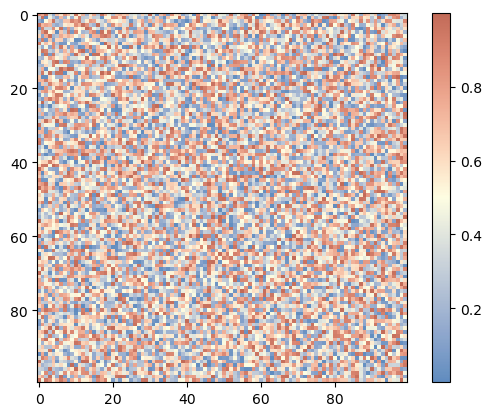

In [ ]:
x = np.random.rand(100,100)
plt.imshow(x, cmap=cmap_test, alpha=0.9)
plt.colorbar()
plt.show()

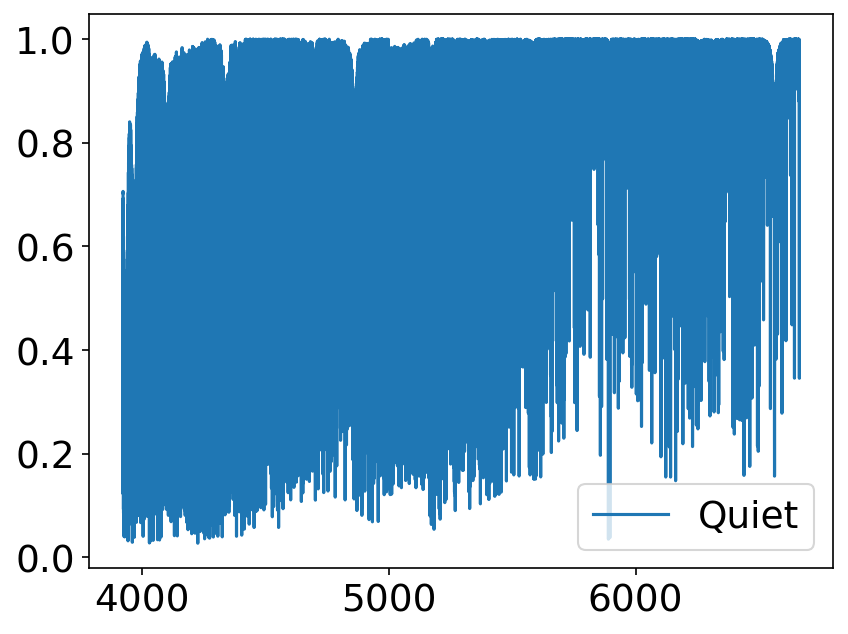

In [36]:
from starsim import nbspectra, spectra
spectra_quiet = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/solar_quiet_spec.txt')
spectra_spot = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/solar_spot_spec.txt')

ss = simulation_init(0,[], [], [], conf_file_path)

rv = np.arange(-ss.ccf_rv_range,ss.ccf_rv_range+ss.ccf_rv_step,ss.ccf_rv_step)


plt.plot(spectra_quiet[:,0], spectra_quiet[:,1], label='Quiet')
# plt.plot(spectra_spot[:,0], spectra_spot[:,1], label='Spot')
plt.legend()
plt.show()

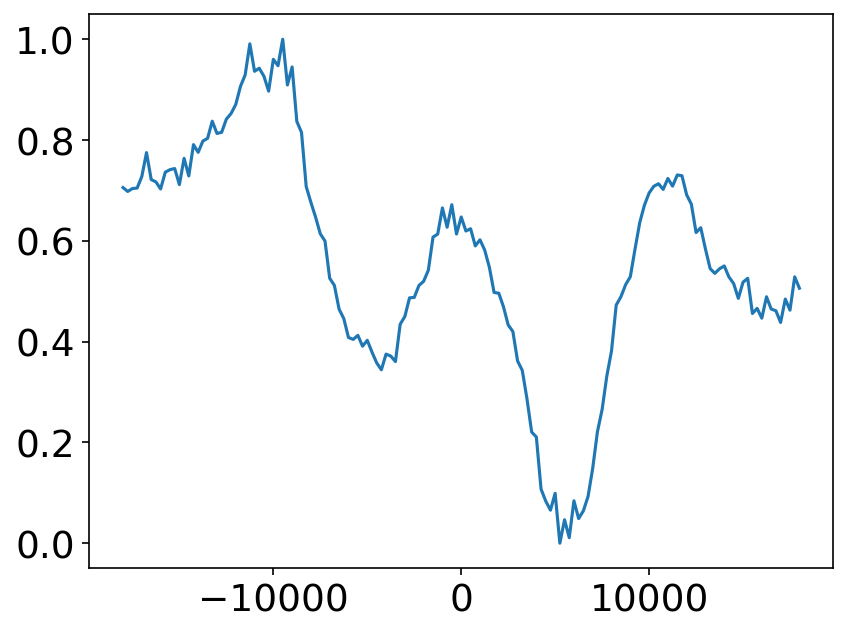

In [37]:
ccf_ph = nbspectra.cross_correlation_mask(rv,np.asarray(spectra_quiet[:,0],dtype='float64'),np.asarray(spectra_quiet[:,1],dtype='float64'),np.asarray(ss.wvm,dtype='float64'),np.asarray(ss.fm,dtype='float64'))
ccf_sp = nbspectra.cross_correlation_mask(rv,np.asarray(spectra_spot[:,1],dtype='float64'),np.asarray(spectra_spot[:,1],dtype='float64'),np.asarray(ss.wvm,dtype='float64'),np.asarray(ss.fm,dtype='float64'))


plt.plot(rv, ccf_ph)

plt.show()

In [38]:
wv_rv, flnp_rv =spectra.interpolate_Phoenix(ss,ss.temperature_photosphere,ss.logg) #returns norm spectra and no normalized, interpolated at T and logg

plt.plot(wv_rv, flnp_rv)
plt.plot(spectra_quiet[:,0], spectra_quiet[:,1], label='Quiet')

ccf_ph = nbspectra.cross_correlation_mask(rv,np.asarray(wv_rv,dtype='float64'),np.asarray(flnp_rv,dtype='float64'),np.asarray(ss.wvm,dtype='float64'),np.asarray(ss.fm,dtype='float64'))


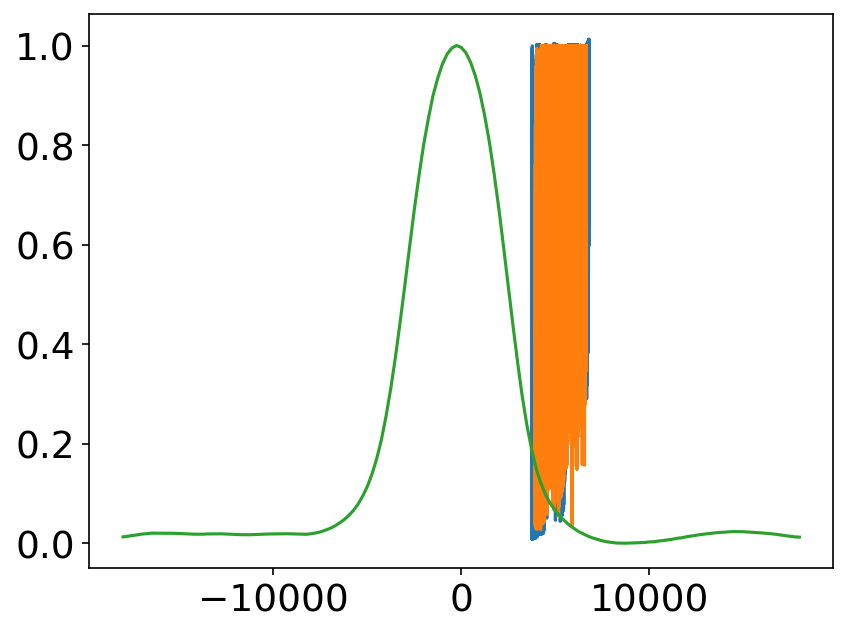

In [39]:
plt.plot(rv, ccf_ph)
plt.show()

In [40]:
file1 = '/home/sophie-stucki/SOAP/solar_CCFs/CCF_solar_spectrum_G2_FTS_reso_not_evenly_sampled_in_freq.rdb'

f = open(file1, 'r')
data = f.readlines()
f.close()

data = data[2:]

rv_ccf = []
ccf_quiet = []
ccf_spot = []


for i in range(len(data)):
    data_i = np.float64(data[i].replace('\n', '').split('\t'))
    rv_ccf.append(data_i[0])
    ccf_quiet.append(data_i[1])
    ccf_spot.append(data_i[2])

rv = 1000 * np.array(rv_ccf)
ccf_spot = (1 - np.array(ccf_spot)) 
ccf_quiet = (1 - np.array(ccf_quiet)) 

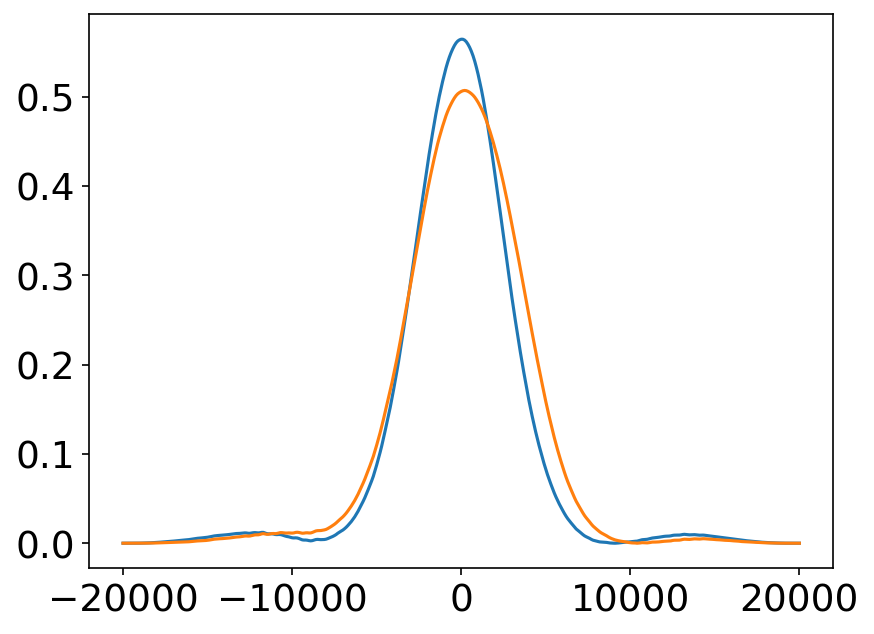

In [41]:
plt.plot(rv, ccf_quiet, label='Quiet')
plt.plot(rv, ccf_spot, label='Spot')
plt.show()

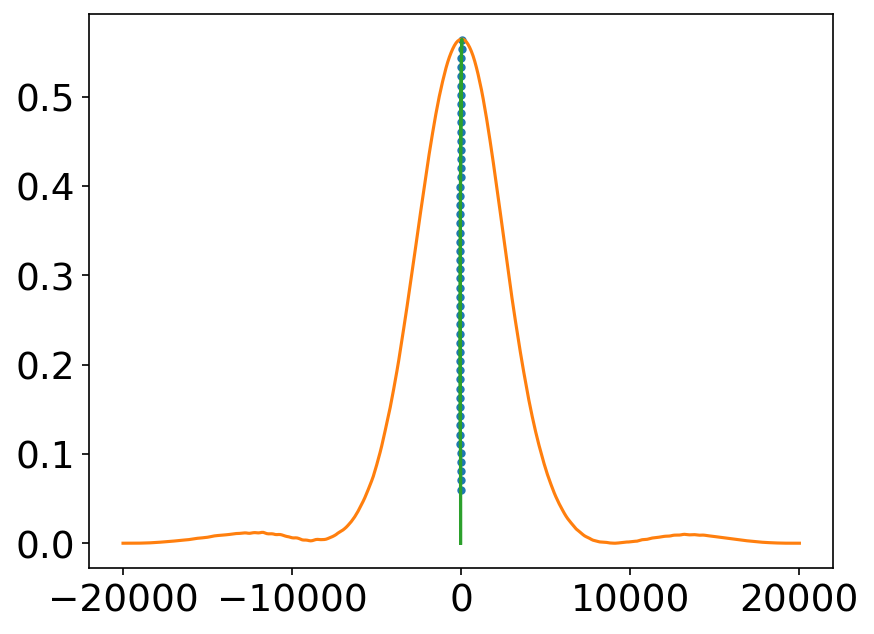

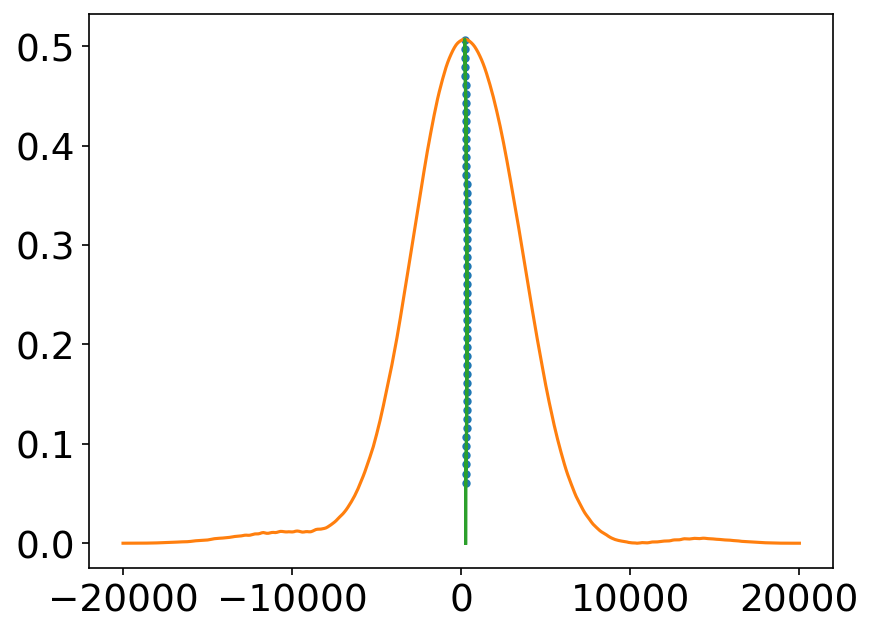

In [42]:
fun_bis_ph = spectra.bisector_fit(ss,rv,ccf_quiet,plot_test=True,kind_interp=ss.kind_interp)
fun_bis_sp = spectra.bisector_fit(ss,rv,ccf_spot,plot_test=True,kind_interp=ss.kind_interp)


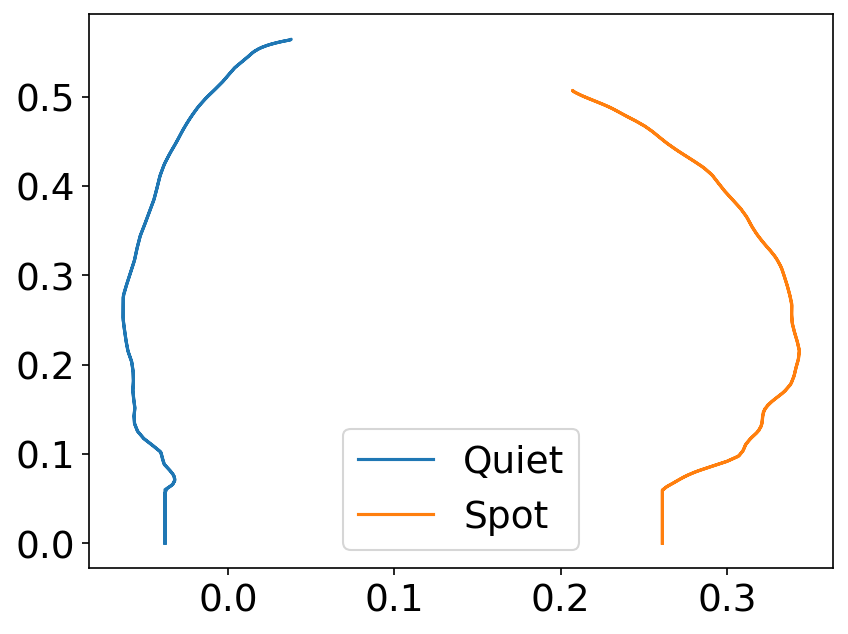

In [43]:
plt.plot(fun_bis_ph(ccf_quiet)/1000, ccf_quiet, label='Quiet')
plt.plot(fun_bis_sp(ccf_spot)/1000, ccf_spot, label='Spot')
plt.legend()
plt.show()

In [44]:
print(np.mean(fun_bis_sp(ccf_spot)) - np.mean(fun_bis_ph(ccf_quiet)))

306.82767478965246


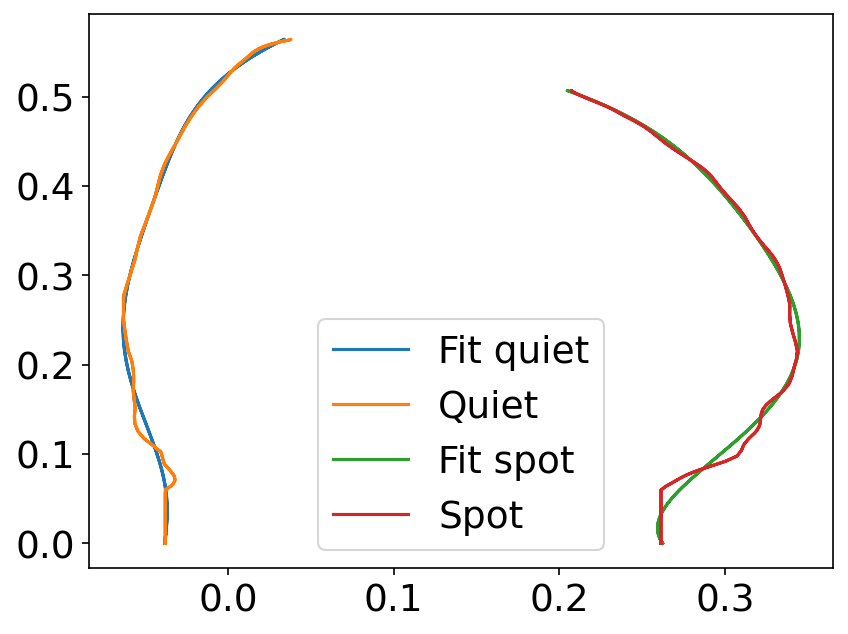

In [45]:
fit_quiet = np.poly1d(np.polyfit(ccf_quiet, fun_bis_ph(ccf_quiet)/1000, 7))
fit_spot = np.poly1d(np.polyfit(ccf_spot, fun_bis_sp(ccf_spot)/1000, 5))

plt.plot(fit_quiet(ccf_quiet), ccf_quiet, label='Fit quiet')
plt.plot(fun_bis_ph(ccf_quiet)/1000, ccf_quiet, label='Quiet')

plt.plot(fit_spot(ccf_spot), ccf_spot, label='Fit spot')
plt.plot(fun_bis_sp(ccf_spot)/1000, ccf_spot, label='Spot')
plt.legend()
plt.show()

In [46]:
def dumusque_coeffs(amu):
    coeffs=np.array([-1.51773453,  3.52774949, -3.18794328,  1.22541774,  -0.22479665]) #Polynomial fit to ccf in Fig 2 of Dumusque 2014, plus 400m/s to match Fig6 in Herrero 2016
    p=np.poly1d(coeffs)
    return p



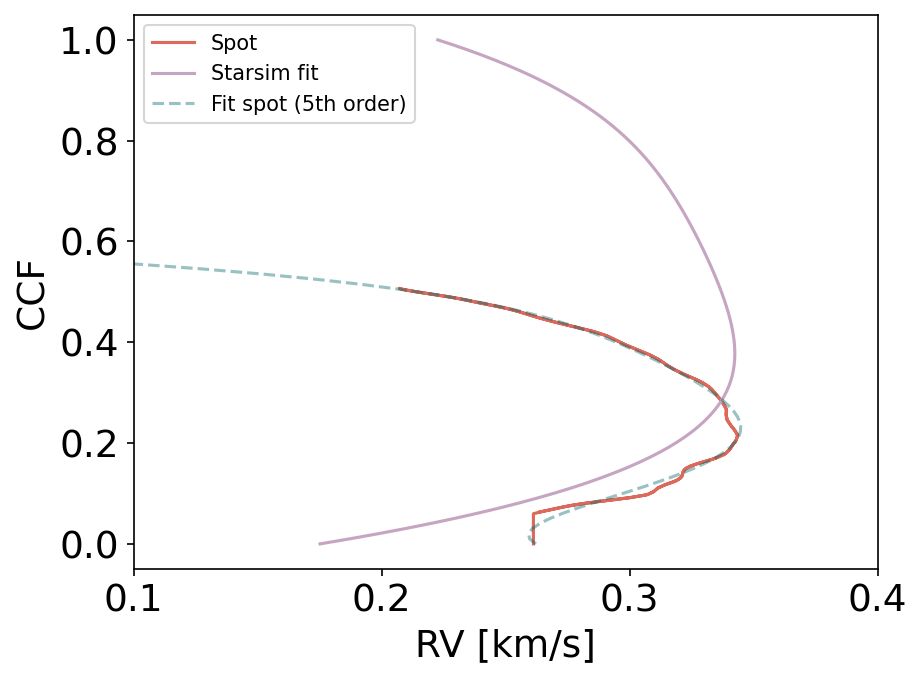

In [67]:
ccf_ss = np.linspace(0,1, 100)
plt.plot(fun_bis_sp(ccf_spot)/1000, ccf_spot, color='#d85a4b', alpha=0.9, label='Spot')
plt.plot(dumusque_coeffs(None)(ccf_ss)+0.4, ccf_ss, color='#c6a5c2',alpha =1,  label='Starsim fit')
plt.plot(fit_spot(ccf_ss), ccf_ss, '--', color='#006666', alpha =0.4, label='Fit spot (5th order)')

plt.legend(fontsize='10')
plt.xlim(0.1,0.4)
plt.xlabel('RV [km/s]')
plt.ylabel('CCF')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/dumusque_fit.pdf', dpi=150, bbox_inches='tight')
plt.show()

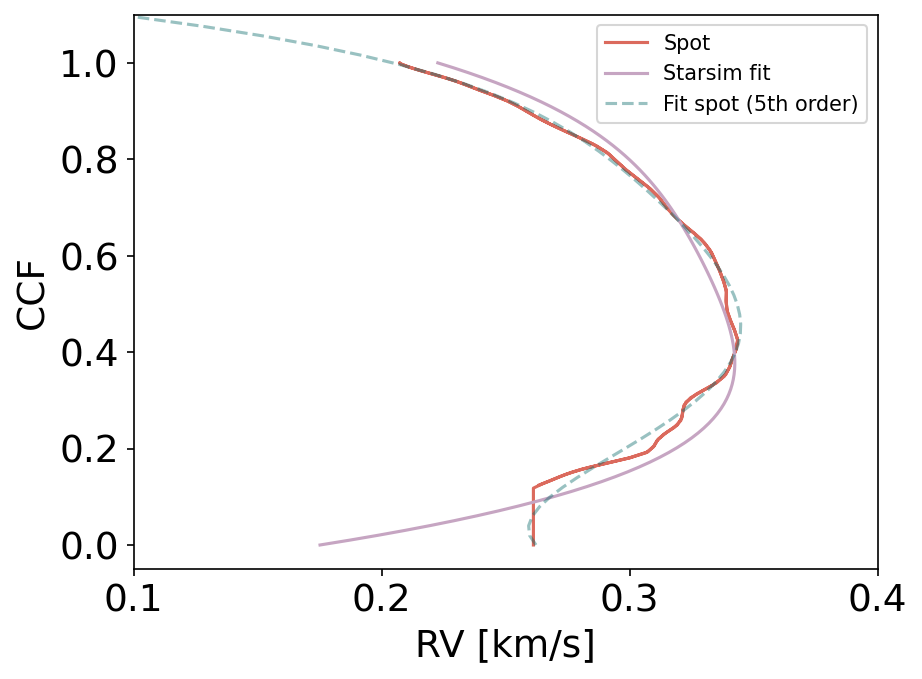

In [68]:
plt.plot(fun_bis_sp(ccf_spot)/1000, ccf_spot/np.max(ccf_spot), color='#d85a4b', alpha=0.9, label='Spot')
plt.plot(dumusque_coeffs(None)(ccf_ss)+0.4, ccf_ss, color='#c6a5c2',alpha =1,  label='Starsim fit')
plt.plot(fit_spot(ccf_ss), ccf_ss/np.max(ccf_spot), '--', color='#006666', alpha =0.4, label='Fit spot (5th order)')

plt.legend(fontsize='10')
plt.xlim(0.1,0.4)
plt.ylim(-0.05,1.1)
plt.xlabel('RV [km/s]')
plt.ylabel('CCF')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/dumusque_fit_norm.pdf', dpi=150, bbox_inches='tight')
plt.show()

Date 10.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [50/50]%00%. [49/50]%%

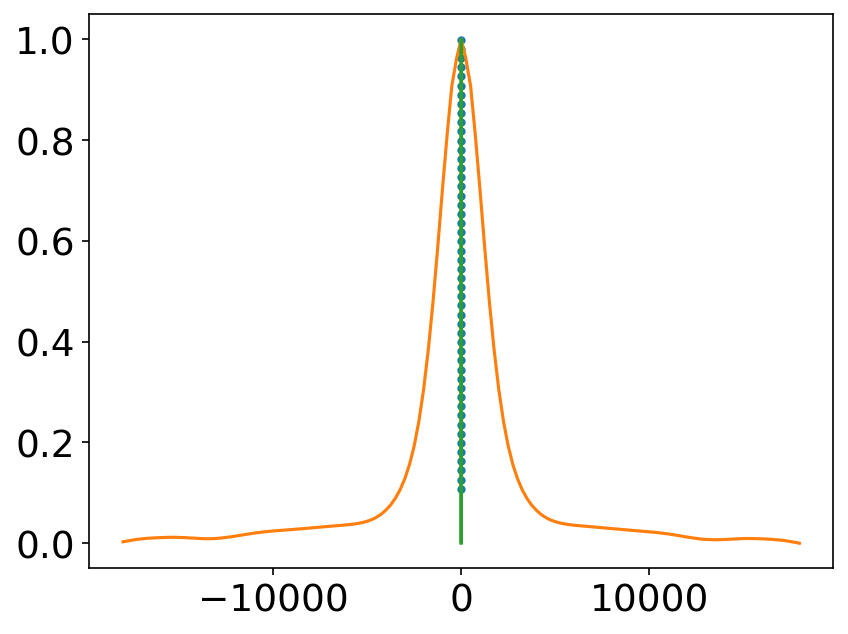

range ccf 0.0 1.0
1.0
0.9863613034027223
0.9458172417006346
0.8794737512064891
0.7891405093963936
0.677281571625741
0.5469481581224269
0.40169542465296937
0.245485487140799
0.08257934547233217
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
CCF:  0.0 1.0
Date 10.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [50/50]%00%. [49/50]%%

In [ ]:
pathdata="/home/sophie-stucki/Documents/starsim_simulations/"
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/home/sophie-stucki/starsim3/starsim/conf/starsim+baroch.conf"

Q = 2
spot_size_list = [5]
latitude_list = [90]
longitude_list = [180]
periods_nbr = 1
point_nbr = 5

ss_old = simulation_init(Q, spot_size_list, latitude_list, longitude_list, conf_file_path, periods_nbr, point_nbr)
    
t=np.linspace(0,10 *periods_nbr,int(10 *periods_nbr*point_nbr))

ss_old.compute_forward(observables=['rv','lc'],t=t, w='eq_2')

MIN:  97.57016891230916
MAX:  100.0
RANGE:  2.429831087690843


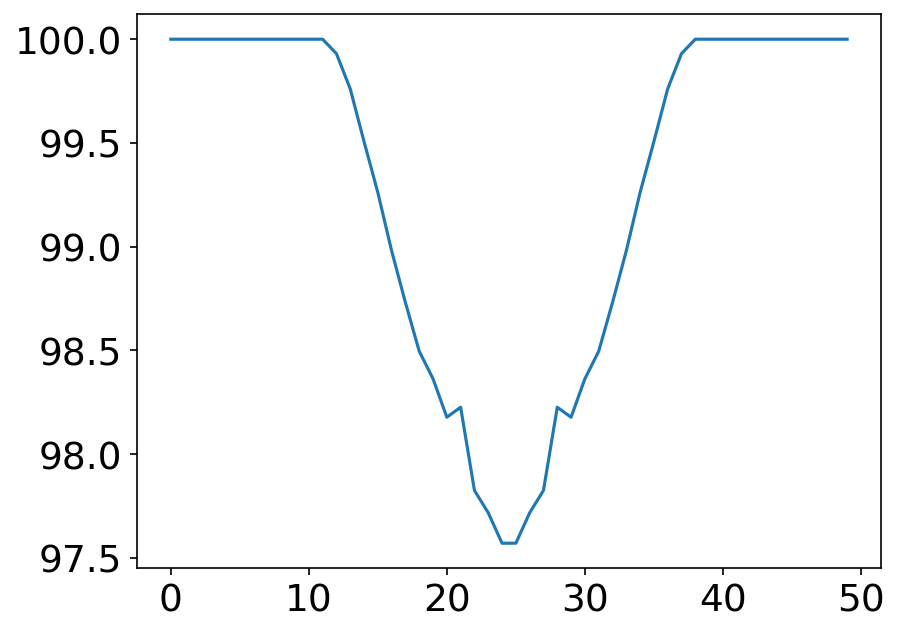

In [42]:
obs = 'ff_ph'

print('MIN: ', np.min(ss_old.results[obs]))
print('MAX: ', np.max(ss_old.results[obs]))
print('RANGE: ', np.max(ss_old.results[obs])-np.min(ss_old.results[obs]))


plt.plot(ss_old.results[obs])
plt.show()


In [103]:
def C_starsim(mu, T_quiet, dT_fc):
    return ((T_quiet + 250.9-407.7*mu+190.9*mu**2 ) / (T_quiet + dT_fc))**4

def C_new(mu, T_quiet, dT_fc):
    return (250.9-407.7*mu+190.9*mu**2)

def C_spec_600(mu, T_quiet, dT_fc):
    return 1 + (1-mu) * 71.190 * (dT_fc / 30.0) * (5778.0 / T_quiet)**2 * (1 / 6000)

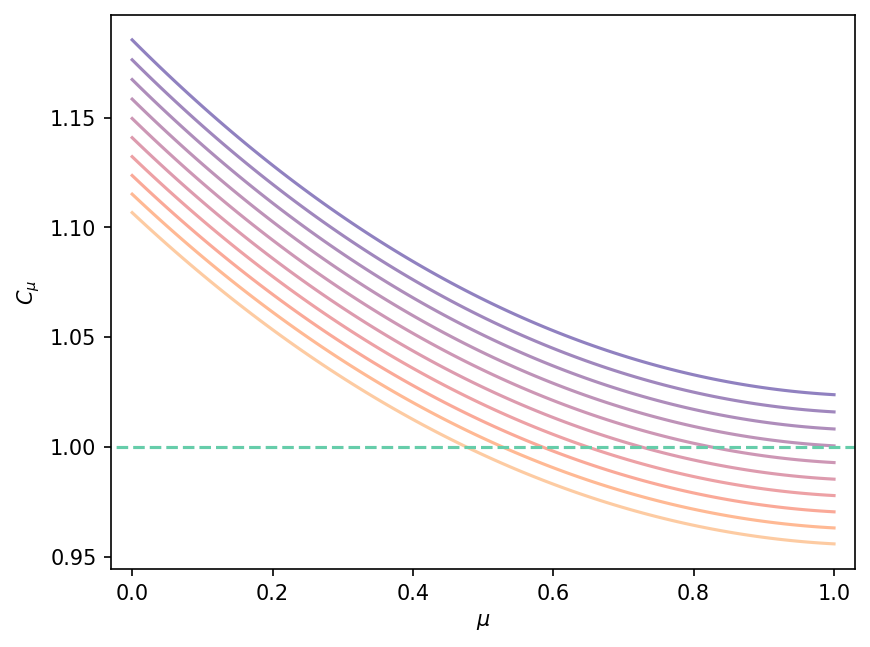

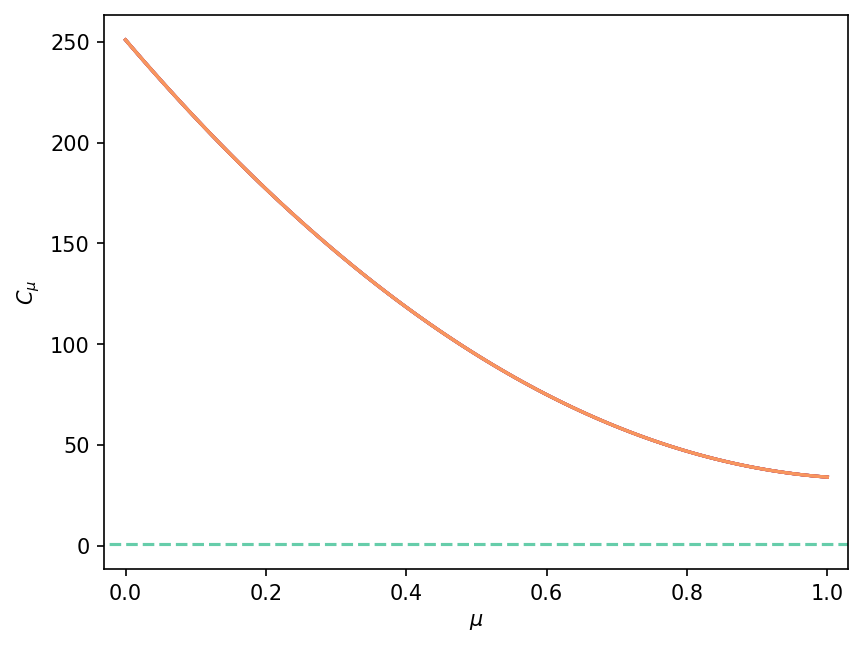

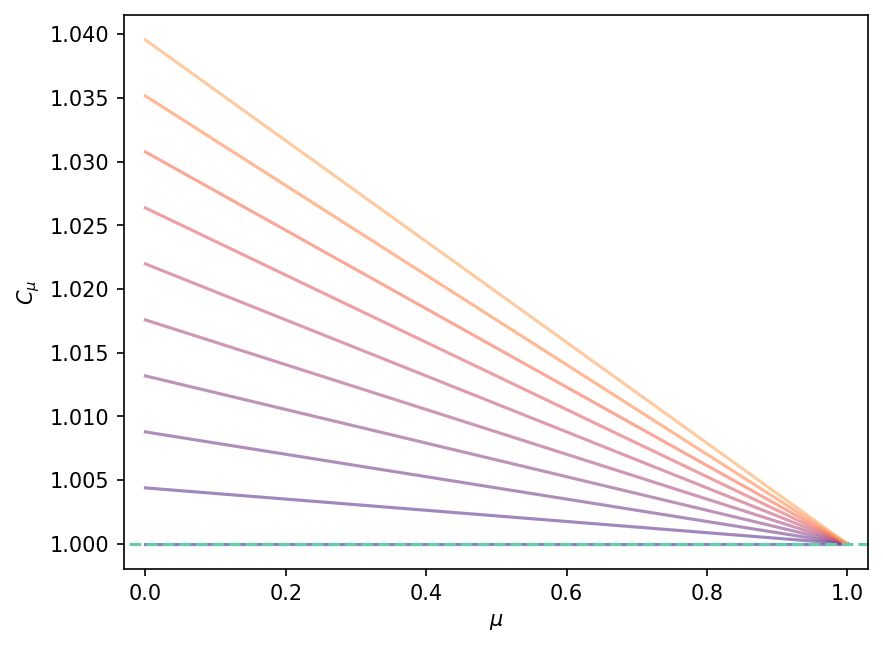

In [ ]:
T_quiet = 5778
dT_fc = 30

dT_fc_list = np.linspace(0,100,n)
mu = np.linspace(0, 1, 100)

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_starsim(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.show()

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_new(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.show()

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_spec_600(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.show()

In [91]:
(T_quiet + dT_fc / 5808 )


5778.005165289256